In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning,
    module="seaborn")

warnings.filterwarnings(
    "ignore",
    message=r"invalid value encountered in log10",
    category=RuntimeWarning,
    module=r".*specparam.*",
)


# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules
from lfp_spike_window_analysis import *
from spk_feat_cluster_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [4]:
cell_num =42 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell 42  
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 42

## Step 0: Get loaded data 

In [5]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c42_lfp.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'


In [6]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

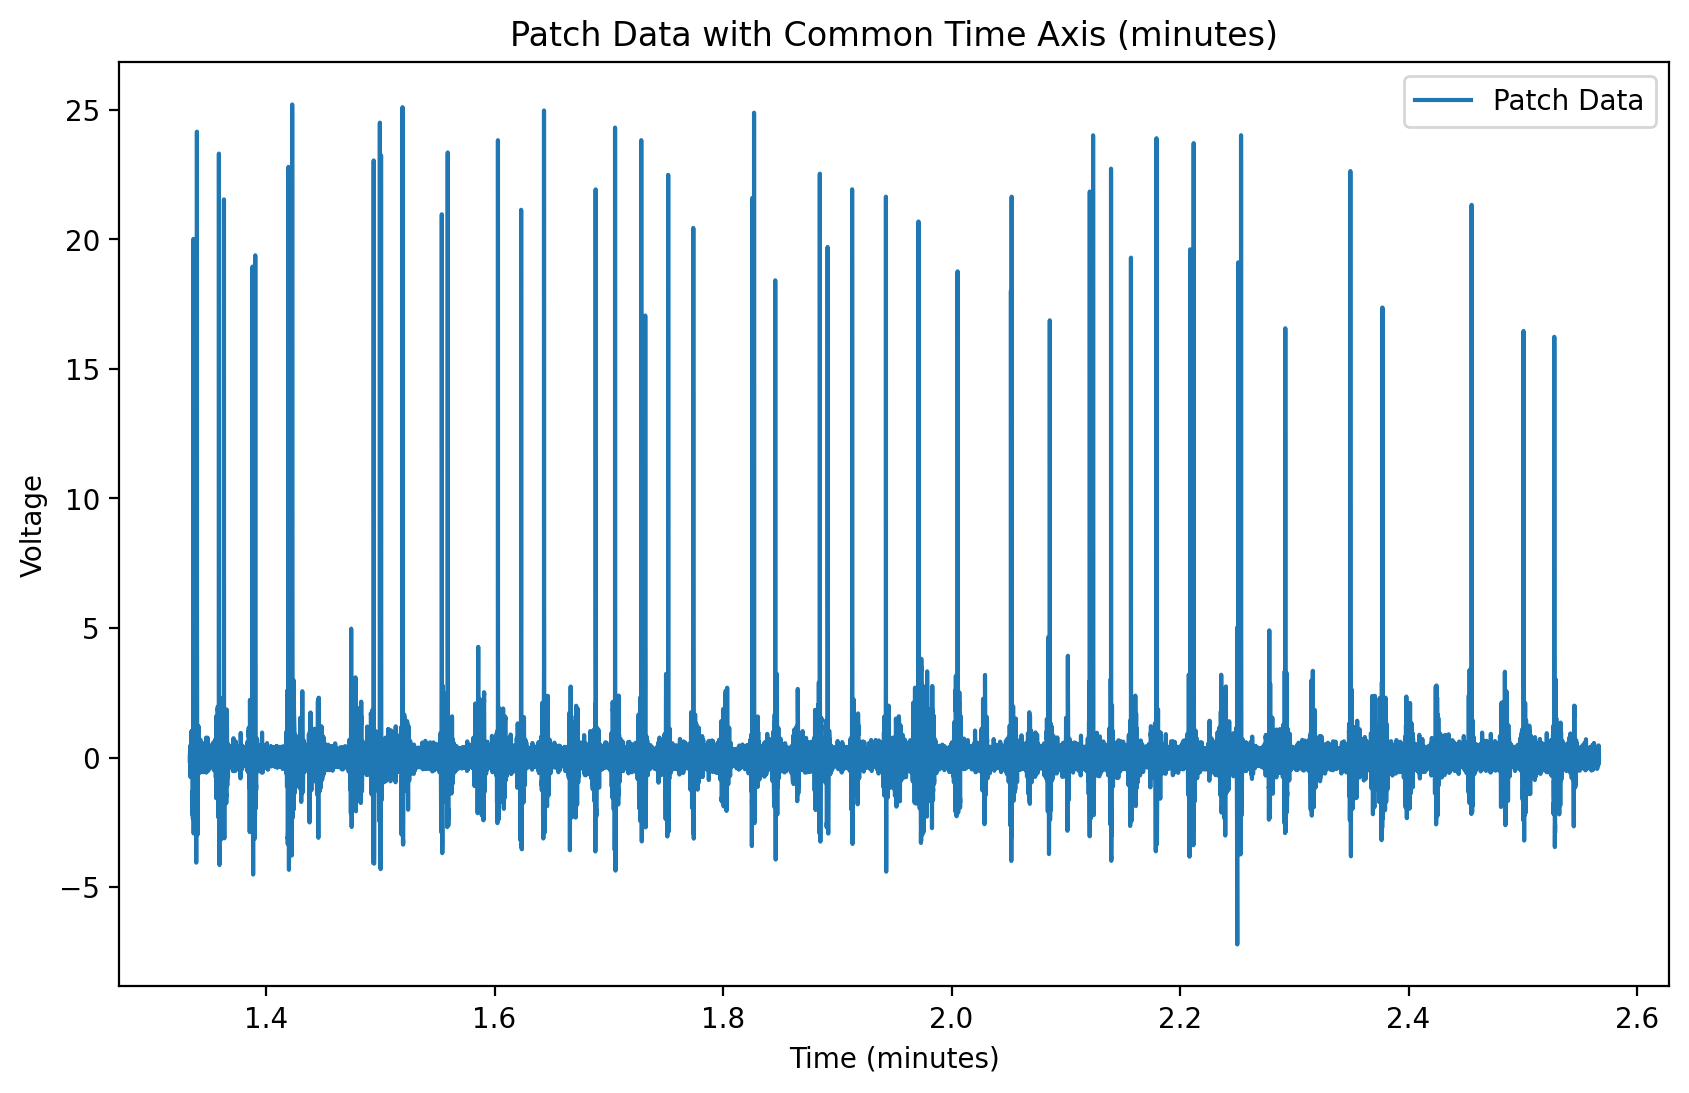

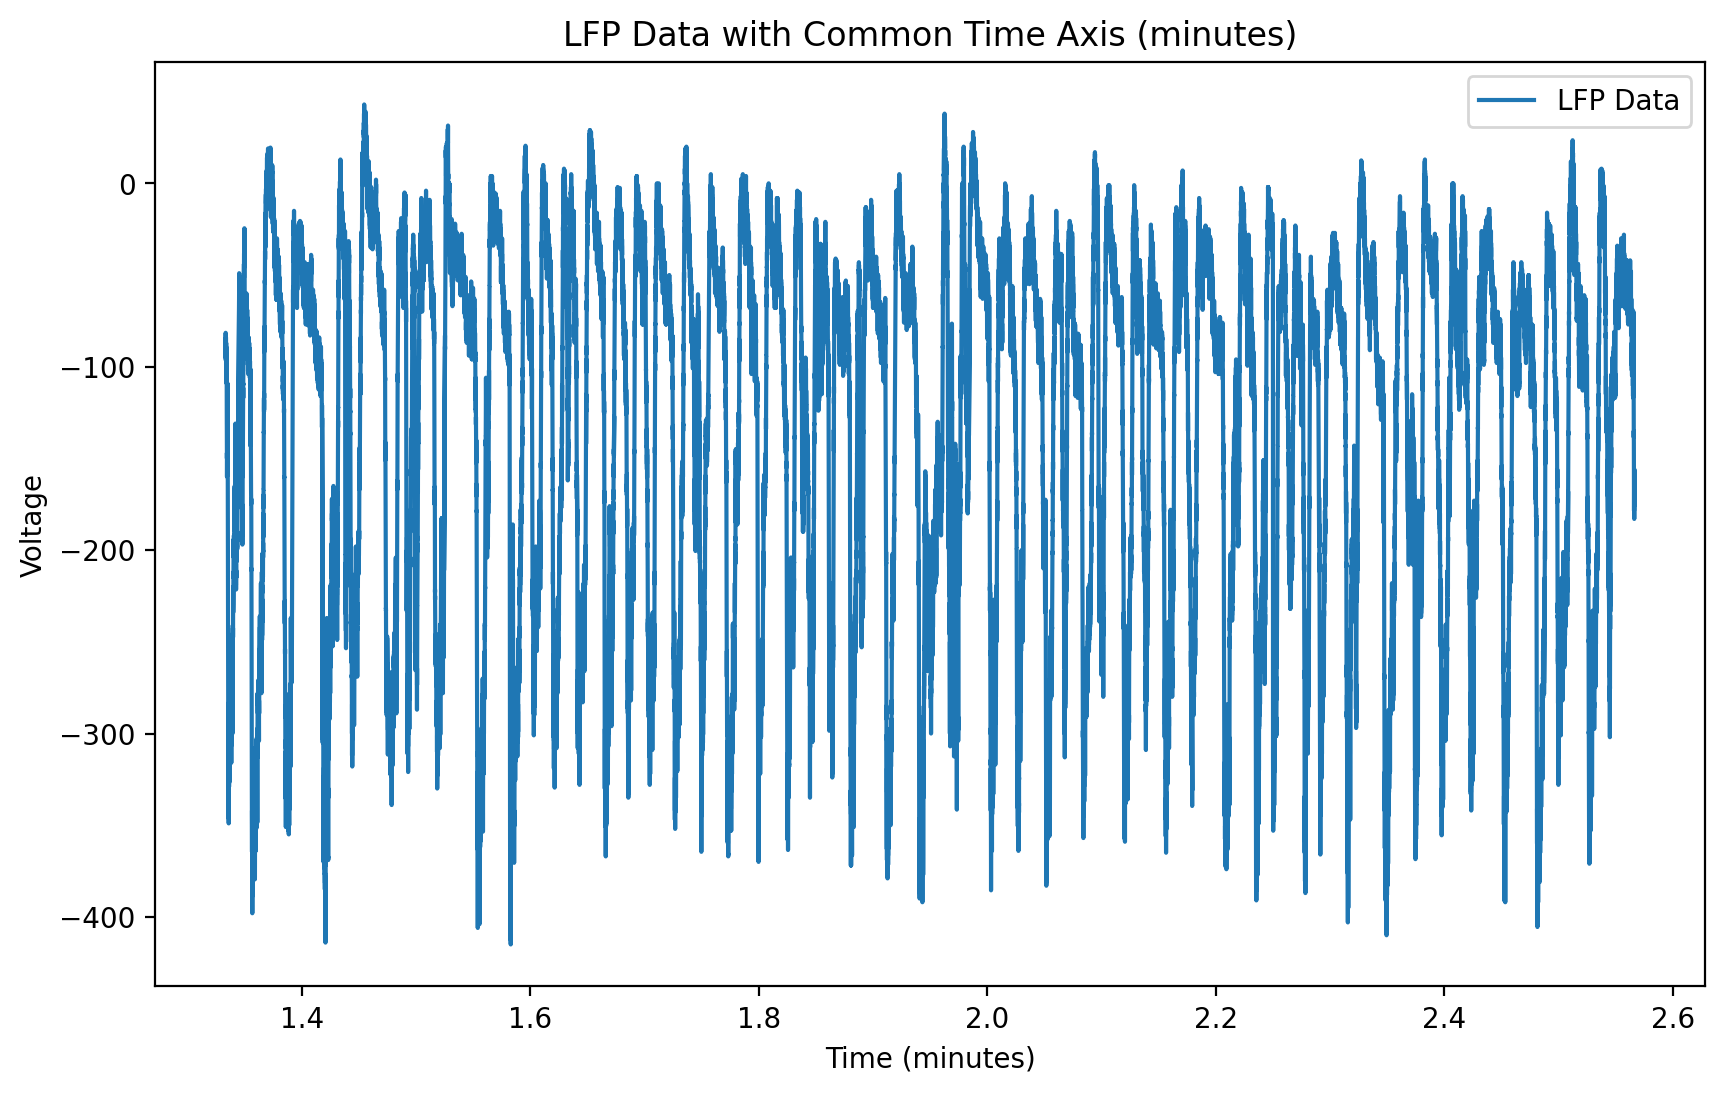

In [7]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: Detect and fit spikes from patch data

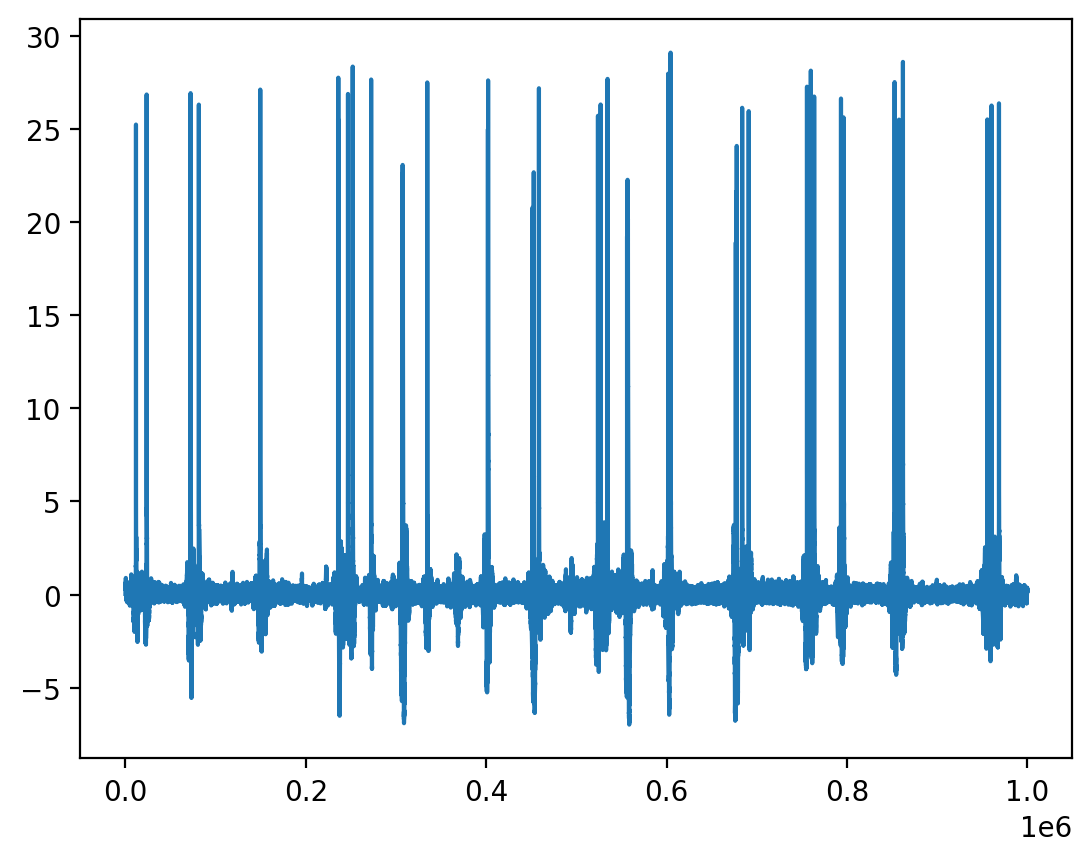

In [8]:
plt.plot(patch_filt[:1000000] )

In [9]:



#threshold in mVs
sp = Spike(thresh_amp=10, window_length=(5., 5.), smooth_frac=.01)

In [10]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=False)

Spike:   0%|▏                                                                                                                   | 1/626 [00:04<43:44,  4.20s/it]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Spike: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 626/626 [00:07<00:00, 82.28it/s]


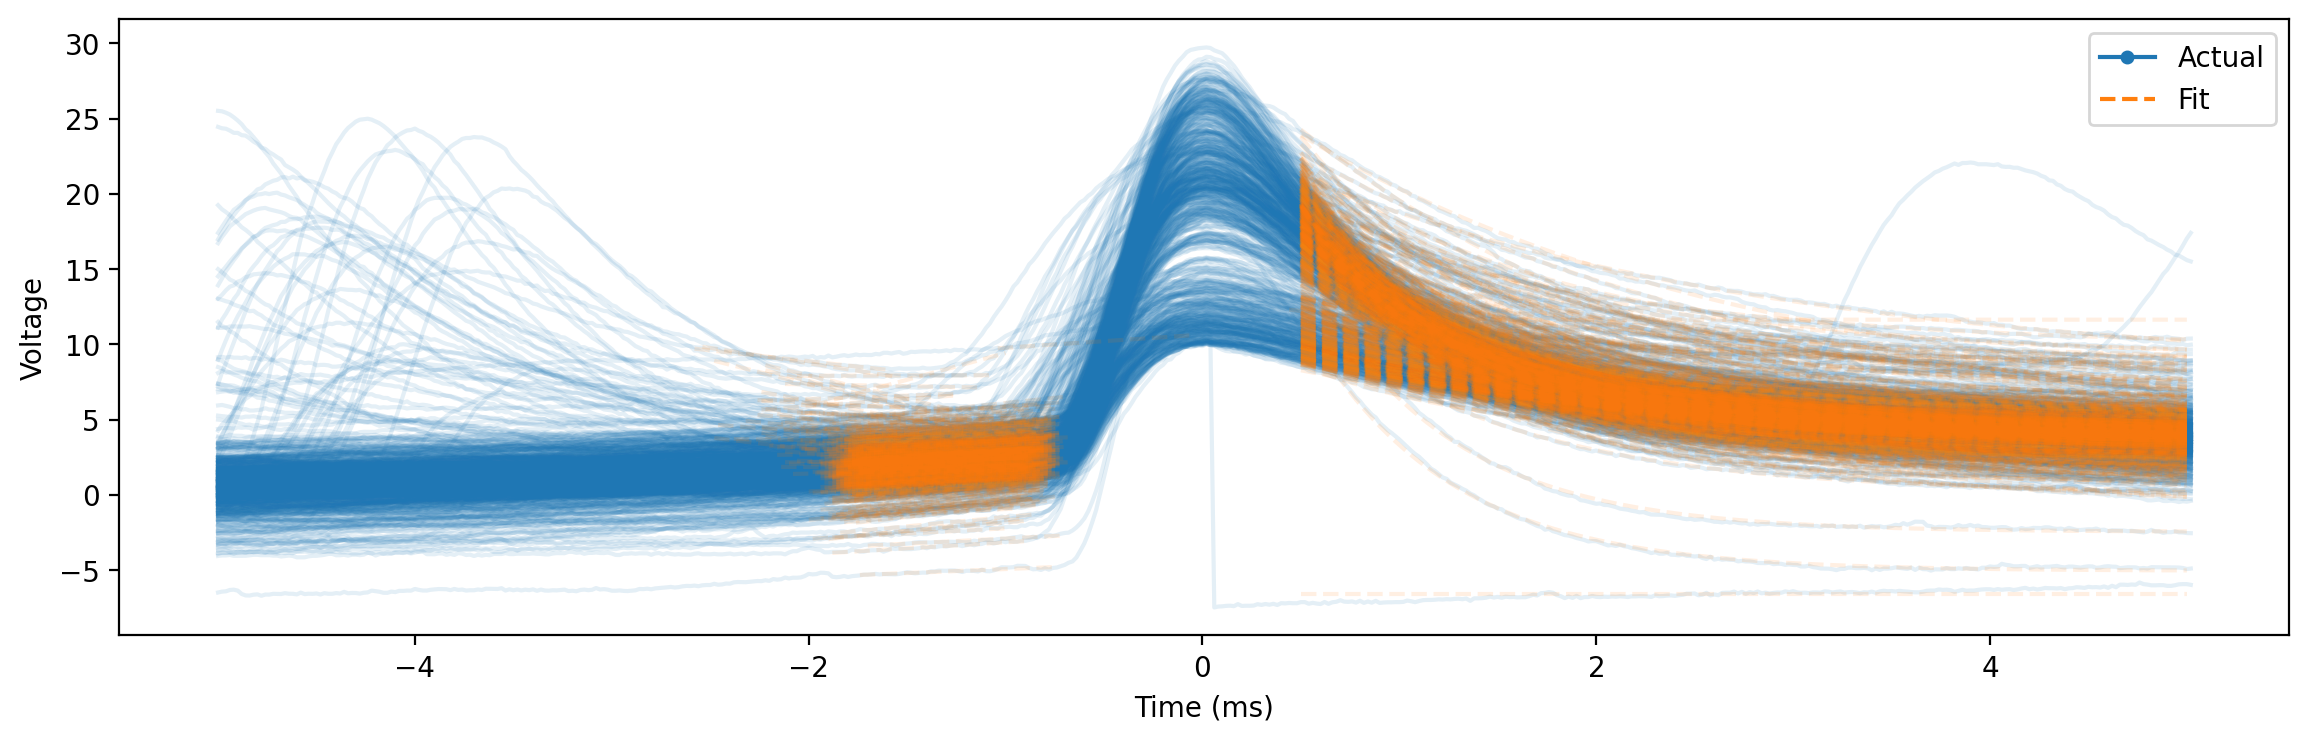

In [11]:
sp.plot()

### Filter spikes 

In [12]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [13]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [14]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,2.373367,11705,233.988239,0
1,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,2.988771,23523,470.235400,1
2,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,2.262434,72270,1444.709957,2
3,1.131318,0.72,3.423346,26.219775,1.14,0.626201,1.488794,3.536553,3.134033,81424,1627.702554,3
4,1.095346,0.72,3.602710,27.026259,1.20,0.577308,1.179299,3.795708,3.238045,149534,2989.252231,4
...,...,...,...,...,...,...,...,...,...,...,...,...
620,-0.265376,1.02,2.682118,10.791884,4.22,0.106704,0.380376,5.169002,3.897371,37325628,746156.170373,606
621,0.517355,0.70,3.353721,10.312721,1.78,0.165035,0.585853,3.846416,3.323366,37720584,754051.519285,607
622,-0.909968,1.02,4.727512,11.676022,3.28,0.151212,0.276106,4.721465,3.219649,37825912,756157.073600,608
624,-0.175349,1.08,4.097930,11.829634,3.78,0.121415,0.237549,4.137374,4.340976,38708847,773807.343230,609


### Get spike times


In [15]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 2: Cluster ISI spike groups 

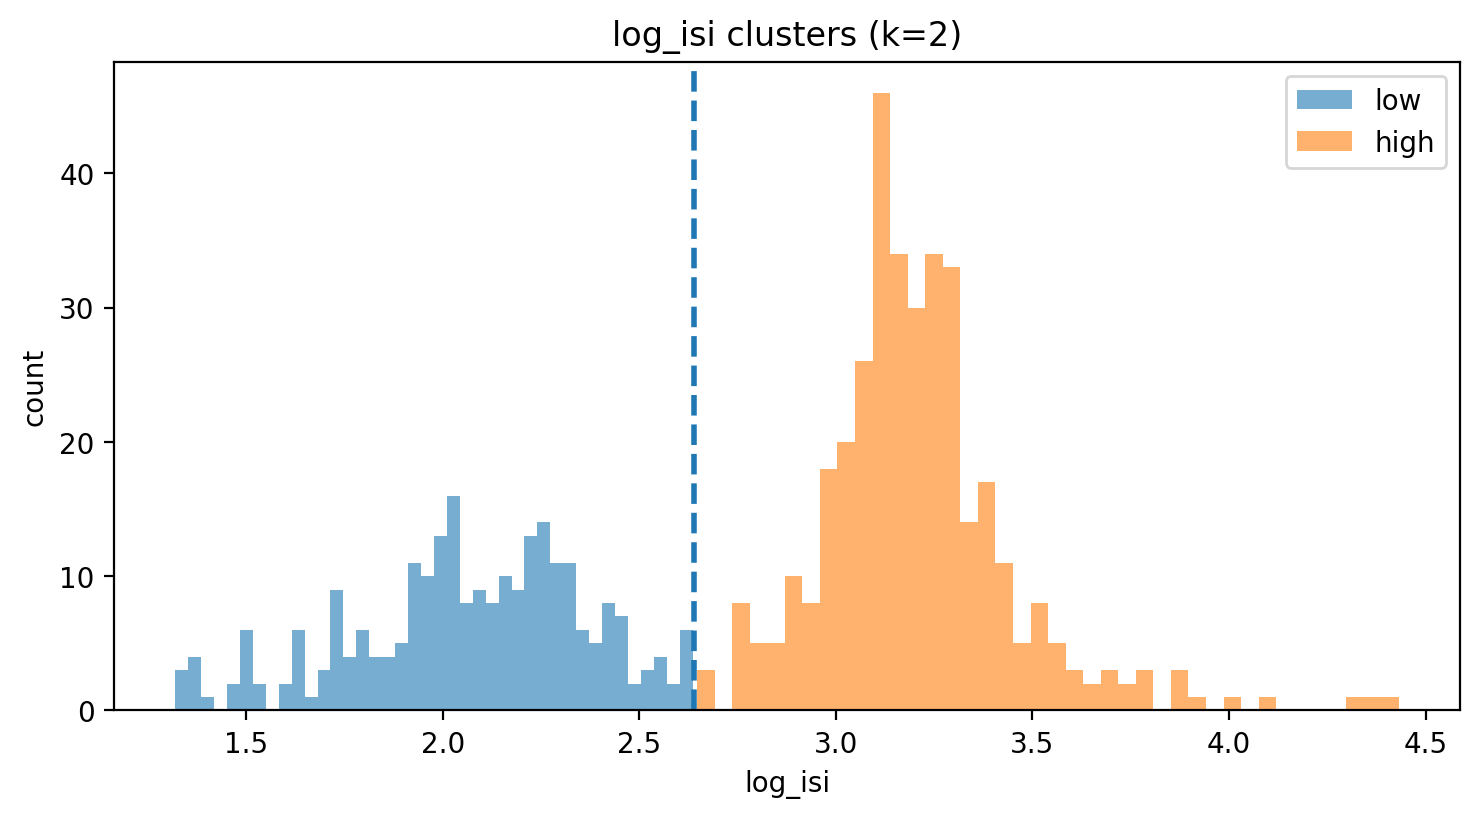

In [16]:
# scan all numeric features and only cluster the ones that look multimodal
df_features_clust, rep = cluster_multimodal_features(
    df_features,
    max_k=3,
    suffix="_cluster",
    plot_each=True  # set True if you want a quick plot per clustered feature
)







### STETP 3: Separate spikes into short ISIs and long ISIs and find transition points (long ISI spikes to group of short ISI spikes)

#### Visualize ISI spike cluster groups over time 

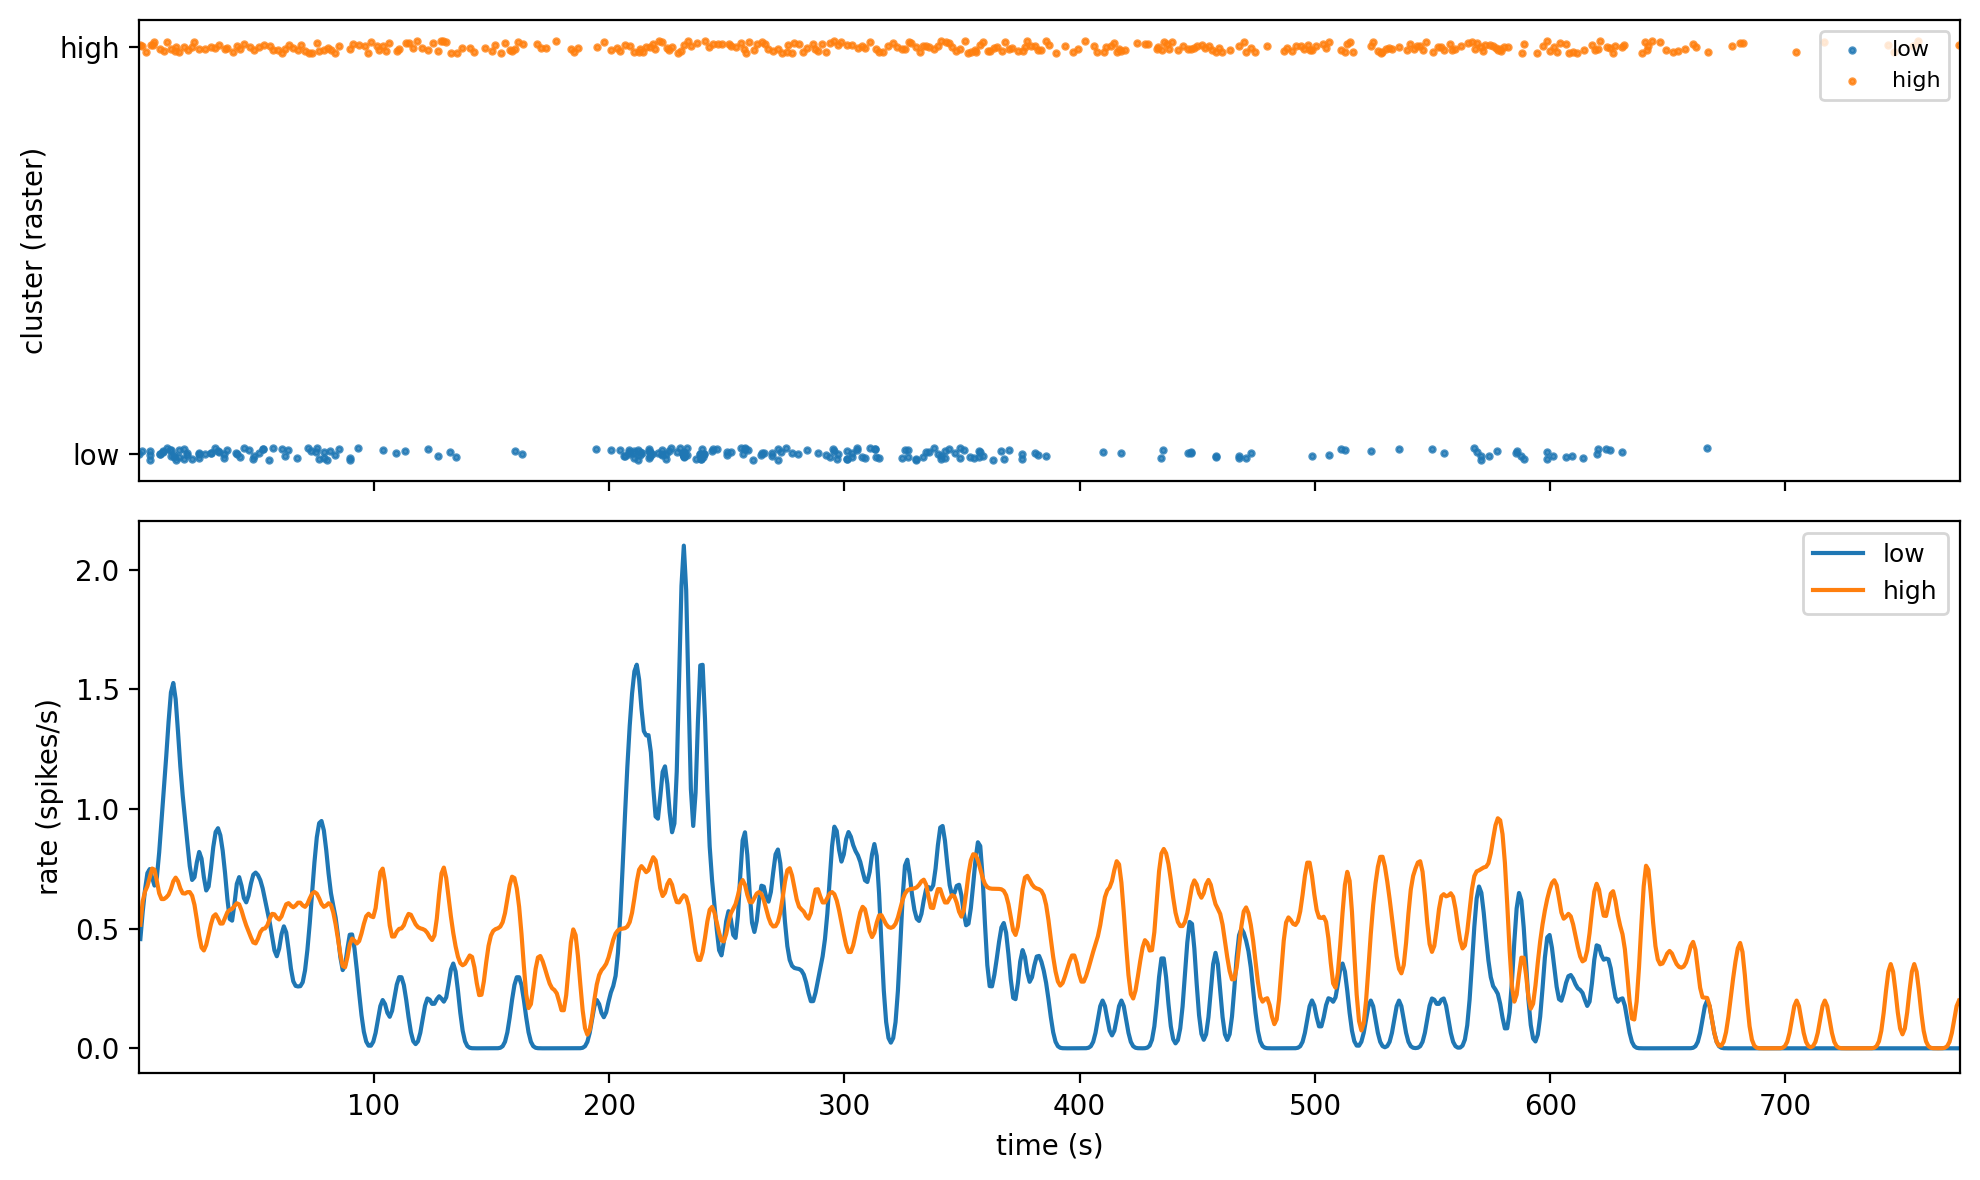

In [17]:
plot_clusters_over_time_min(
    df_features_clust,
    time_col="spk_times_ms",
    label_col="log_isi_cluster",   
    time_unit="ms",
    bin_size_ms=1000,
    sigma_bins=2
)


#### Calculate transition probabilities 

          high       low
high  0.537396  0.462604
low   0.677419  0.322581


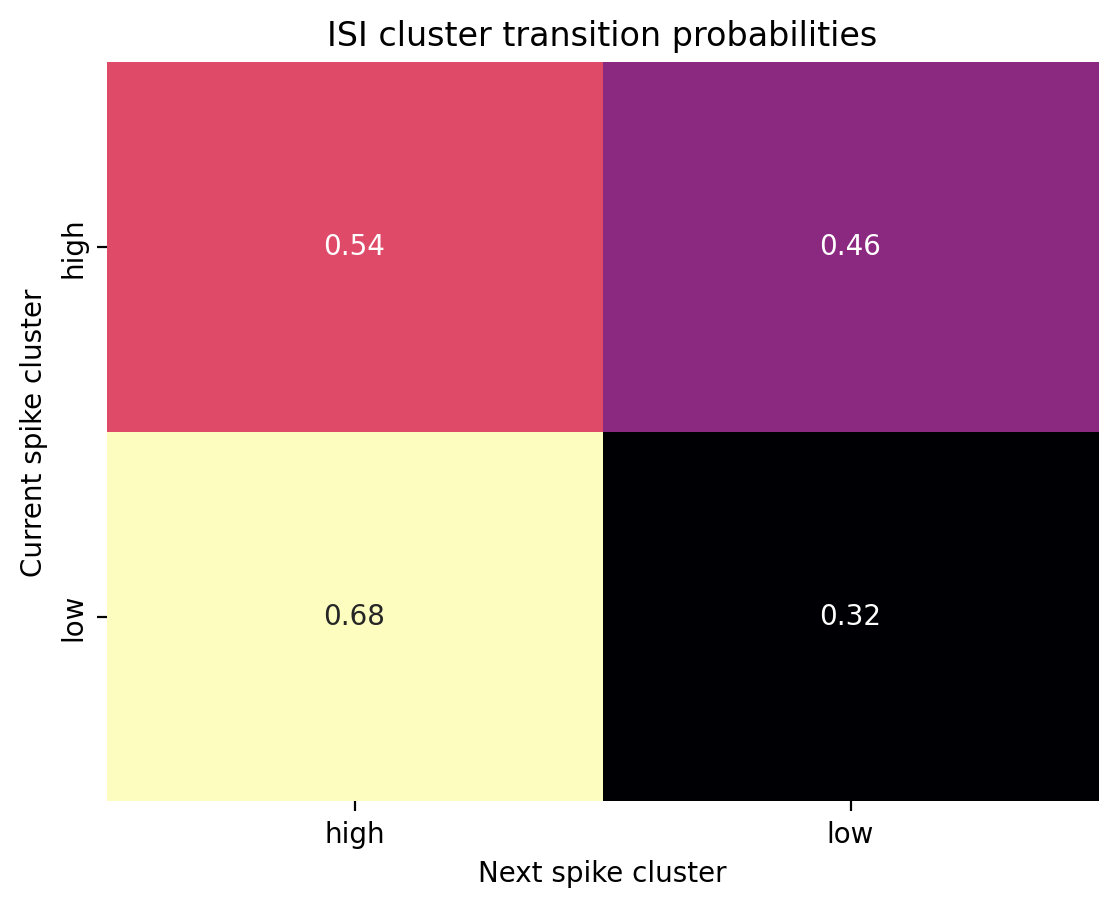

In [18]:
trans_mat = isi_transition_matrix(df_features_clust, "log_isi_cluster")
print(trans_mat)

sns.heatmap(trans_mat, annot=True, cmap="magma", cbar=False)
plt.title("ISI cluster transition probabilities")
plt.xlabel("Next spike cluster")
plt.ylabel("Current spike cluster")
plt.show()


#### Find transition points 

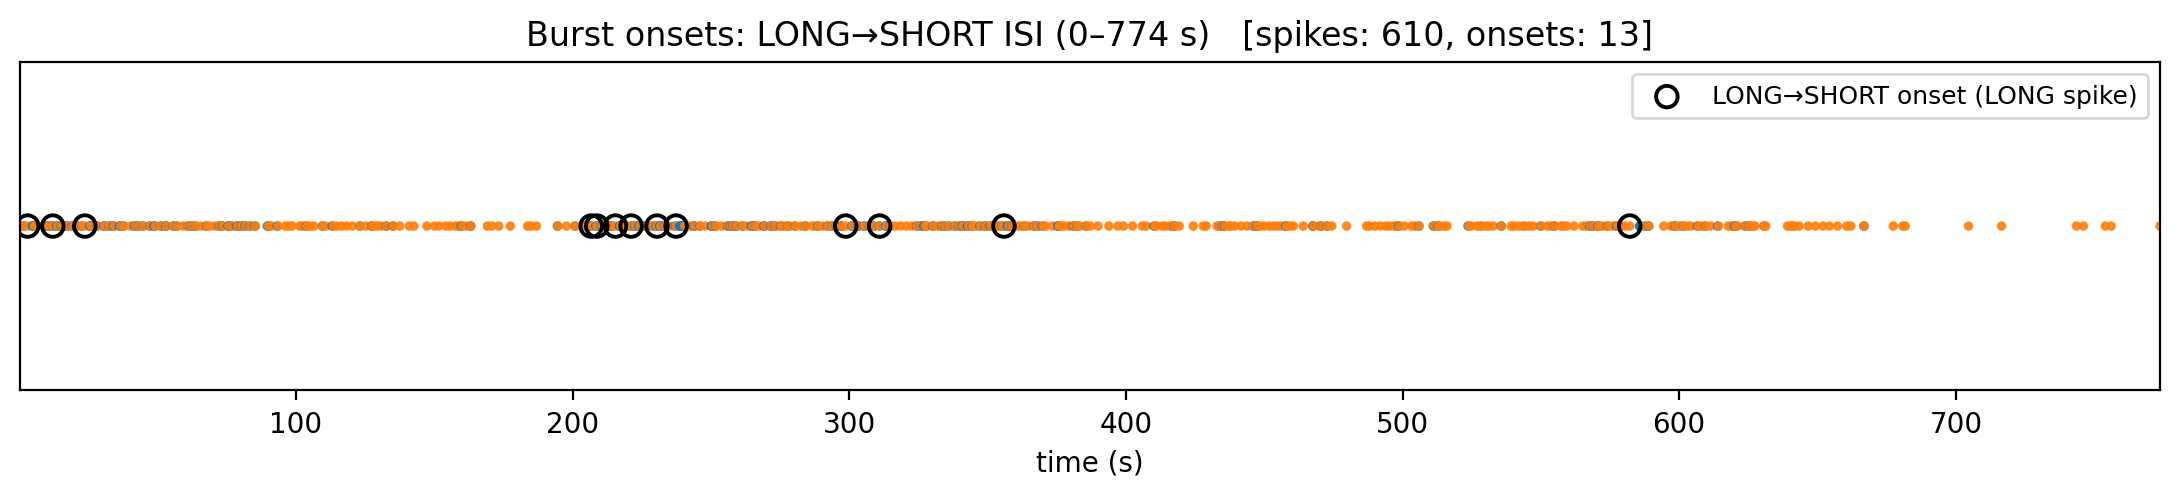

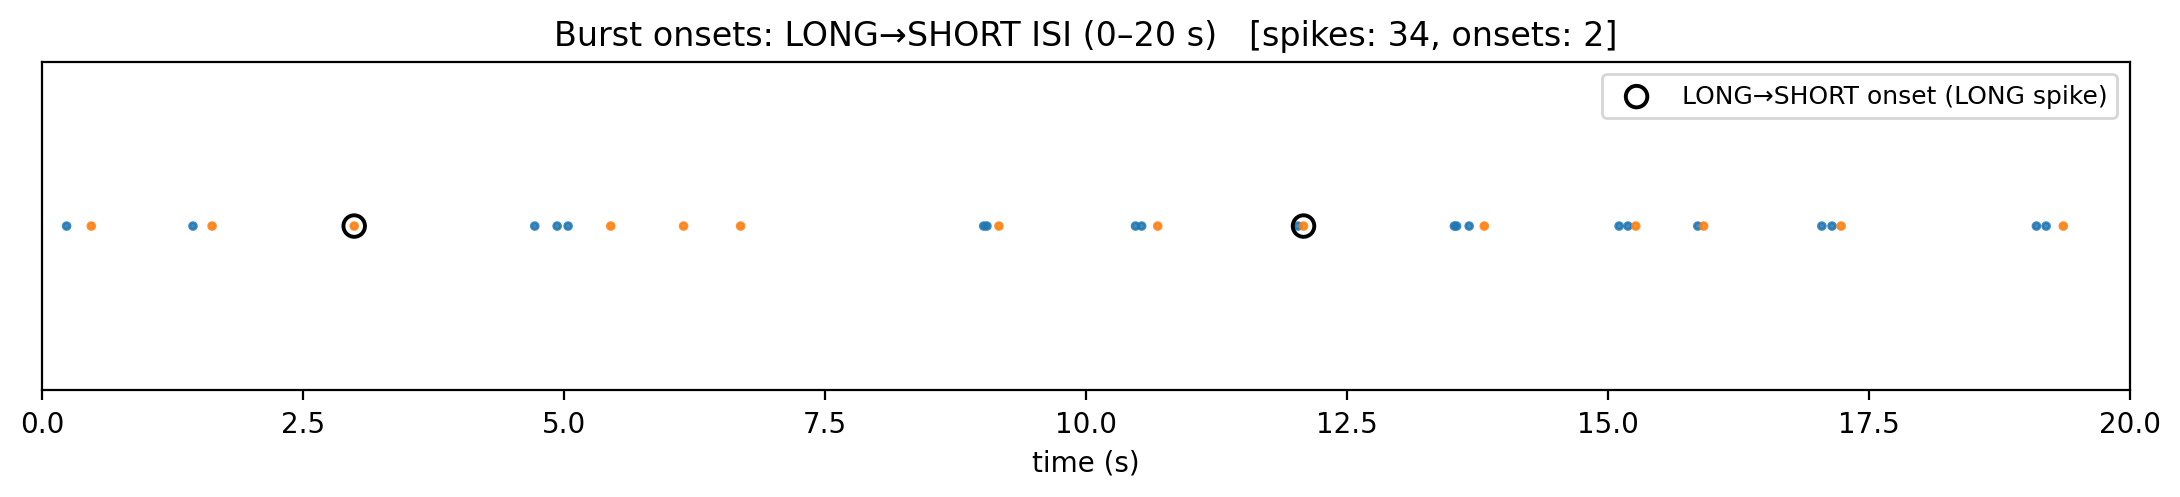

In [19]:
# Identify high spikes that start low bursts
df_marked = mark_high_burst_onsets(
    df_features_clust,
    cluster_col="log_isi_cluster",
    time_col="spk_times_ms",
    min_low_run=3  # how many LOW spikes must follow to count as a burst
)

# Plot full timeline
plot_long_to_short_isi_onsets(
    df_marked,
    time_col="spk_times_ms",
    cluster_col="log_isi_cluster"          

)


# Zoom into a specific range 
plot_long_to_short_isi_onsets(
    df_marked,
    time_col="spk_times_ms",
    cluster_col="log_isi_cluster",
    time_range=(00, 20)  # seconds
)


In [20]:
df_marked

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id,log_isi_cluster,is_long_to_short_isi_onset
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,2.373367,11705,233.988239,0,low,False
1,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,2.988771,23523,470.235400,1,high,False
2,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,2.262434,72270,1444.709957,2,low,False
3,1.131318,0.72,3.423346,26.219775,1.14,0.626201,1.488794,3.536553,3.134033,81424,1627.702554,3,high,False
4,1.095346,0.72,3.602710,27.026259,1.20,0.577308,1.179299,3.795708,3.238045,149534,2989.252231,4,high,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,-0.265376,1.02,2.682118,10.791884,4.22,0.106704,0.380376,5.169002,3.897371,37325628,746156.170373,606,high,False
607,0.517355,0.70,3.353721,10.312721,1.78,0.165035,0.585853,3.846416,3.323366,37720584,754051.519285,607,high,False
608,-0.909968,1.02,4.727512,11.676022,3.28,0.151212,0.276106,4.721465,3.219649,37825912,756157.073600,608,high,False
609,-0.175349,1.08,4.097930,11.829634,3.78,0.121415,0.237549,4.137374,4.340976,38708847,773807.343230,609,high,False


#### Look at the other waveform features for the "transition" spikes
There are no significant differences in the waveform features forr the transition spikes vs other spikes


Comparing groups: high (long ISI ) vs low (short ISI) using column 'log_isi_cluster'

peak_width          : Welch t-test  (p=0.0000)
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


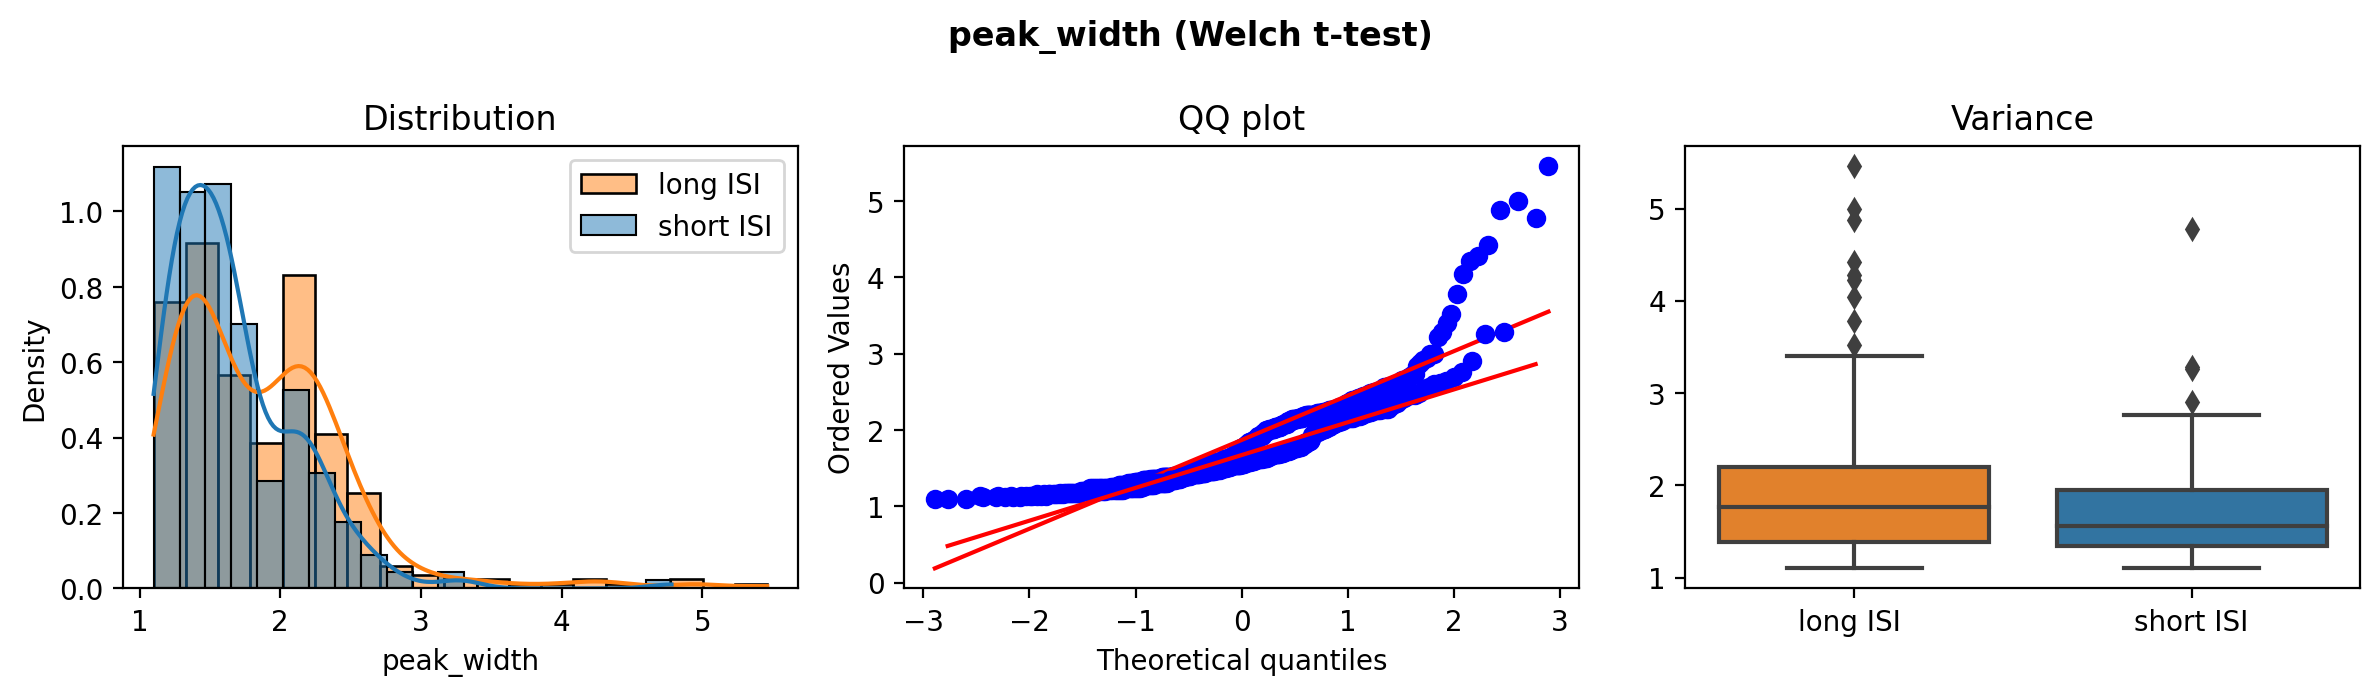

ramp_amp            : t-test        (p=0.0202)


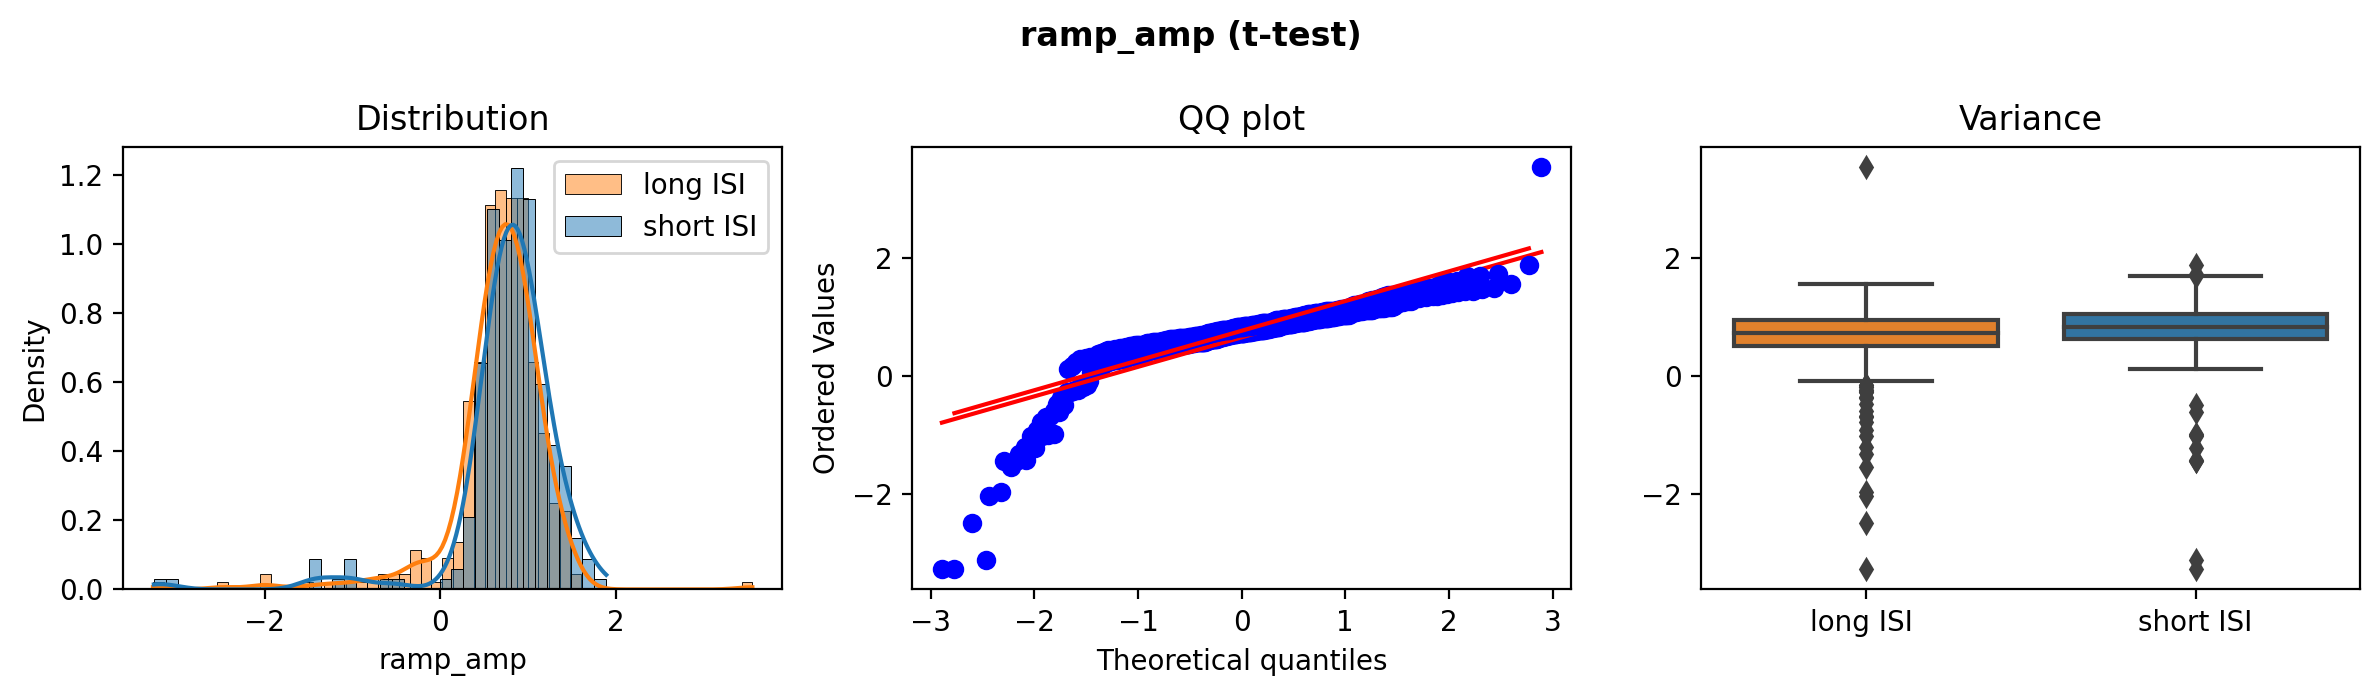

peak_sharpness      : t-test        (p=0.0000)


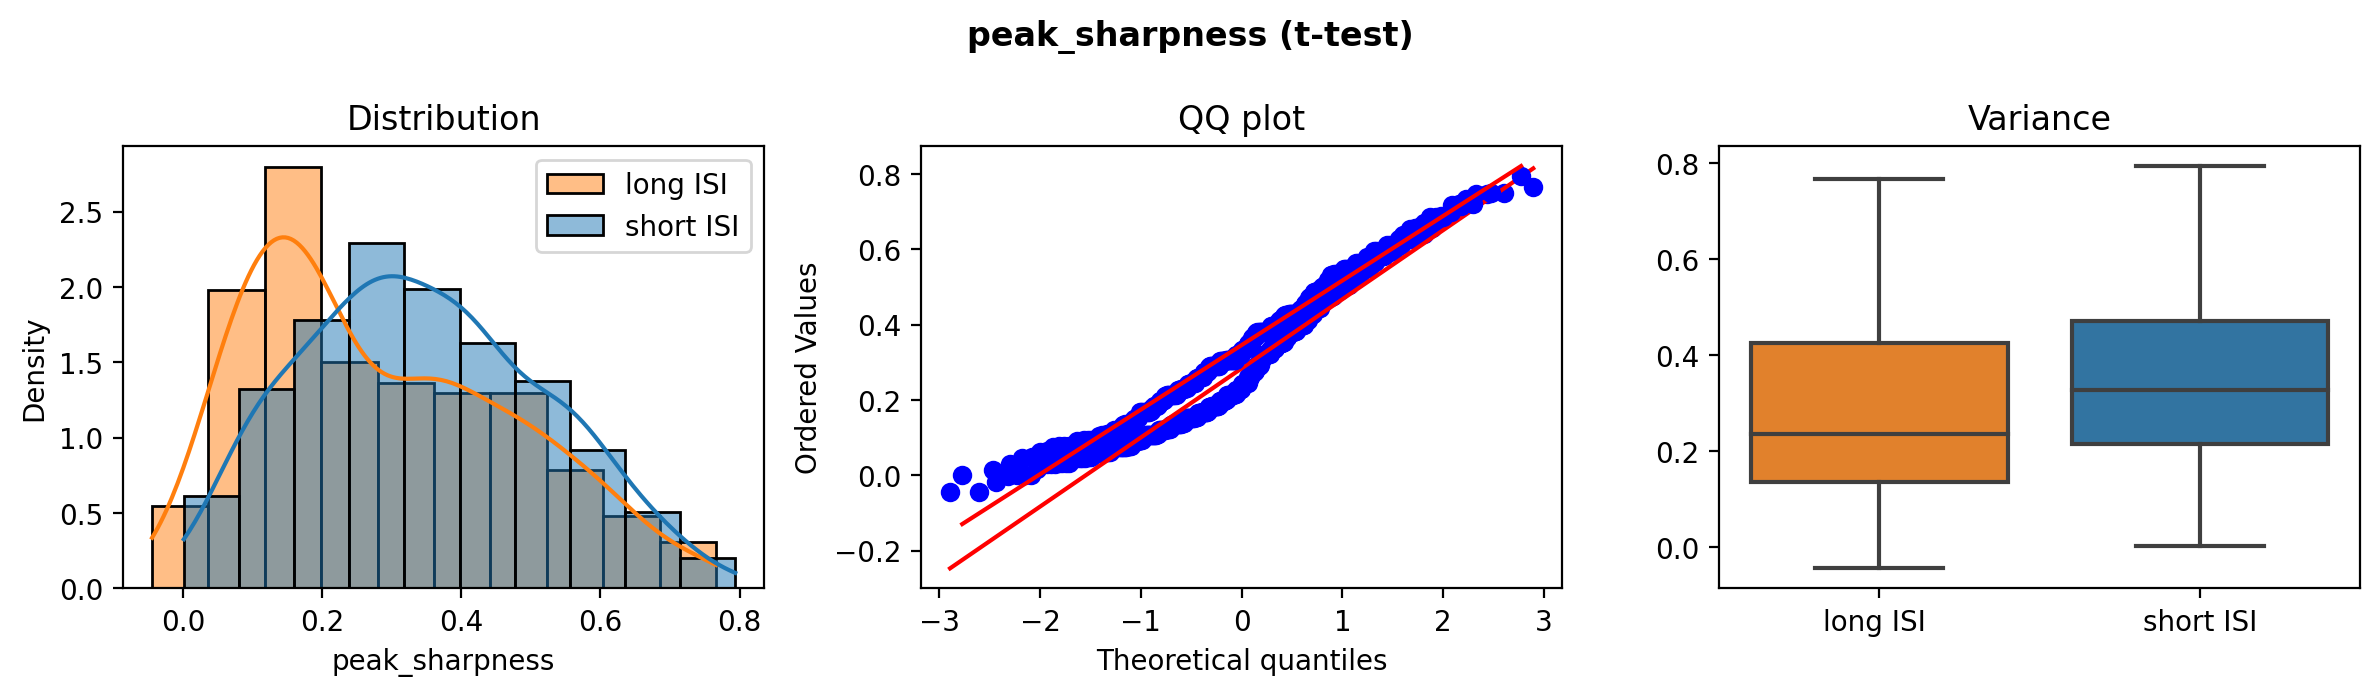

inflection_amp      : t-test        (p=0.1849)


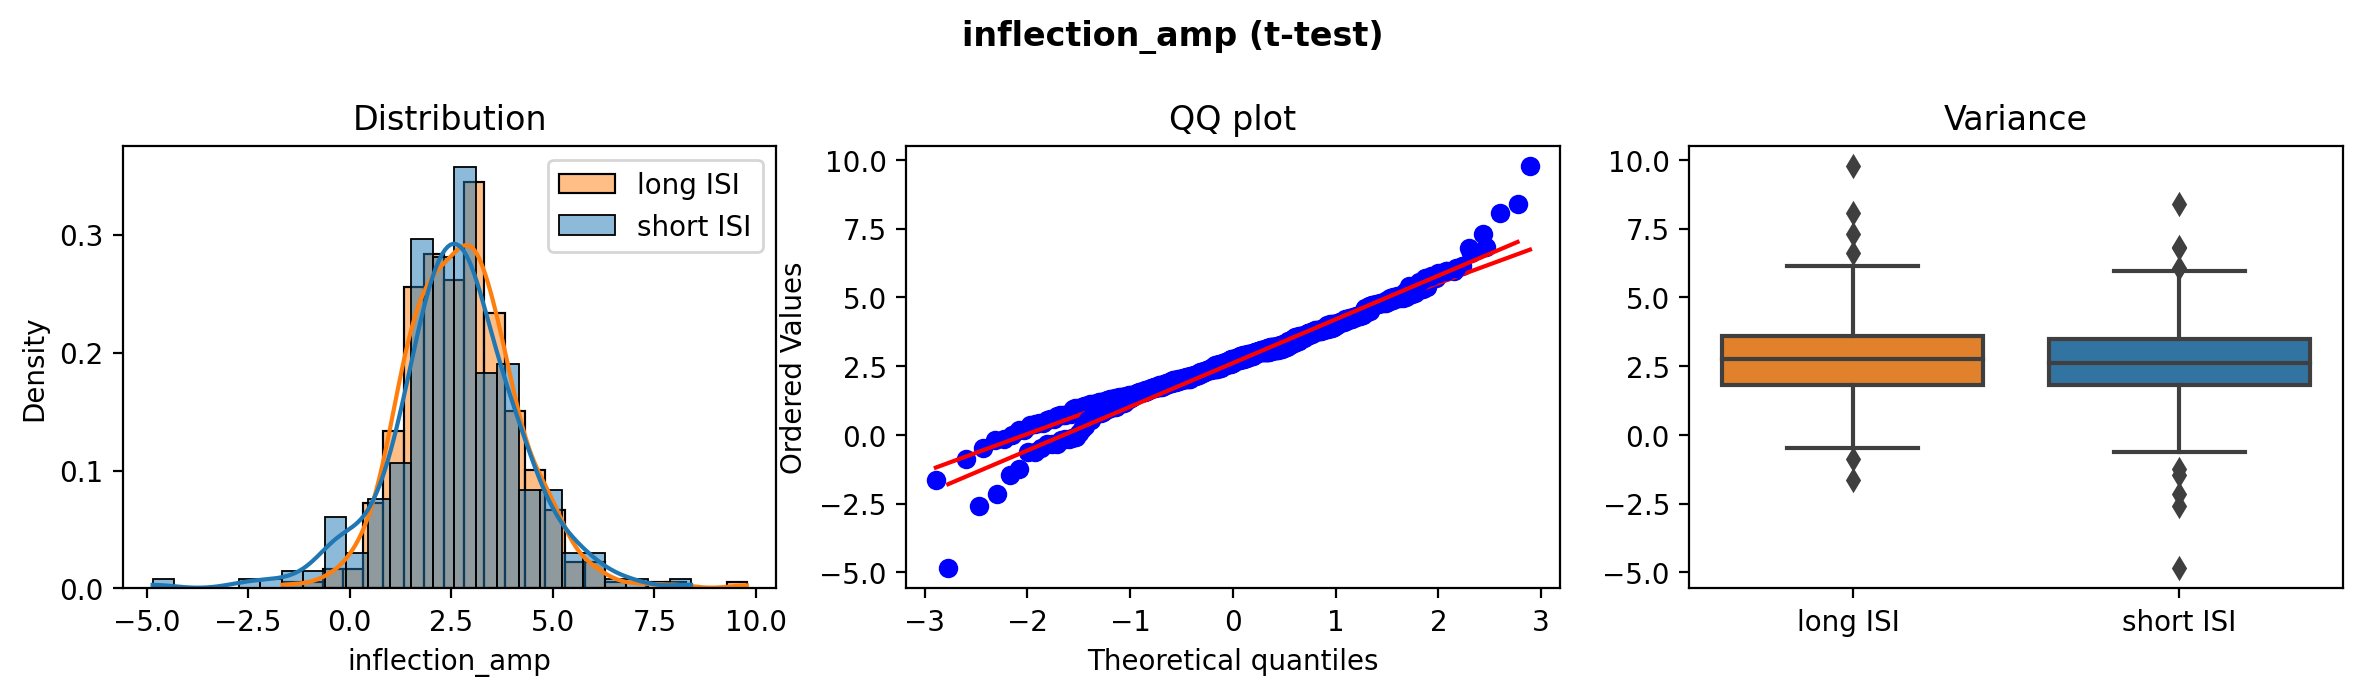

exp_lambda          : Welch t-test  (p=0.0014)


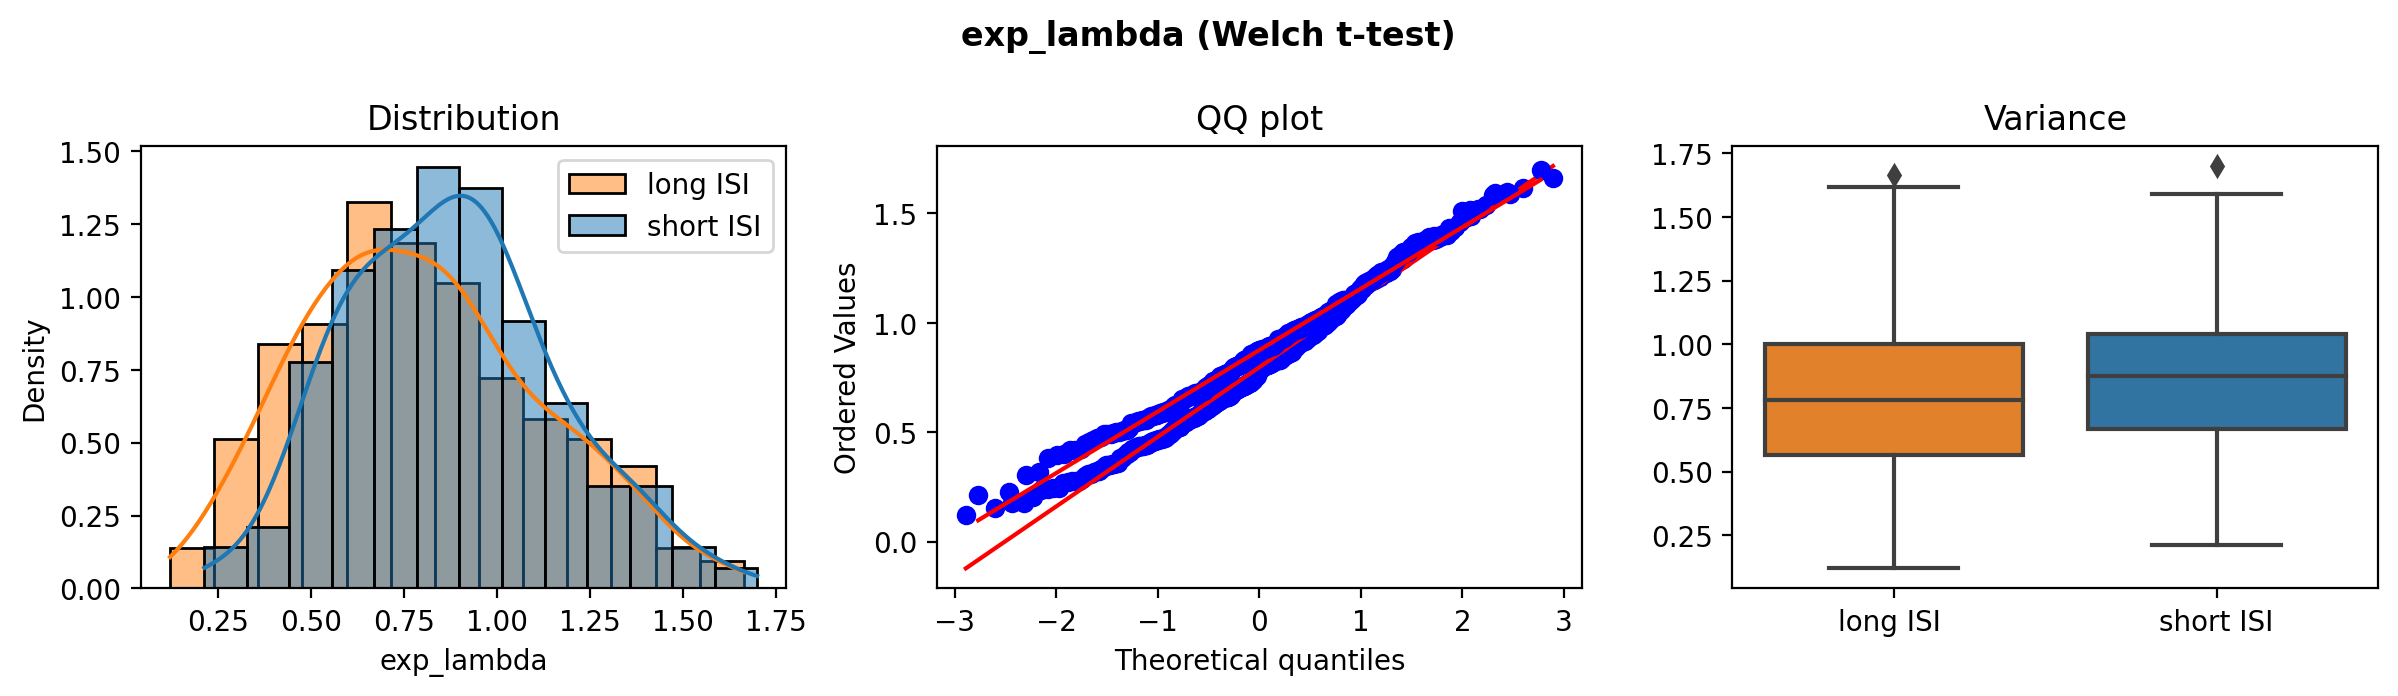

In [21]:
results_isi =  compare_feature_groups(
    df_marked,
    features= ["peak_width","ramp_amp","peak_sharpness", "inflection_amp", "exp_lambda"],
    group_col="log_isi_cluster",
    groups=("high", "low"),              
    group_names=("long ISI ", "short ISI"),  
    show_plots=True
)


Comparing groups: True (transition spike ) vs False (non-transition spike ) using column 'is_long_to_short_isi_onset'

peak_width          : Mann–Whitney  (p=0.0309)


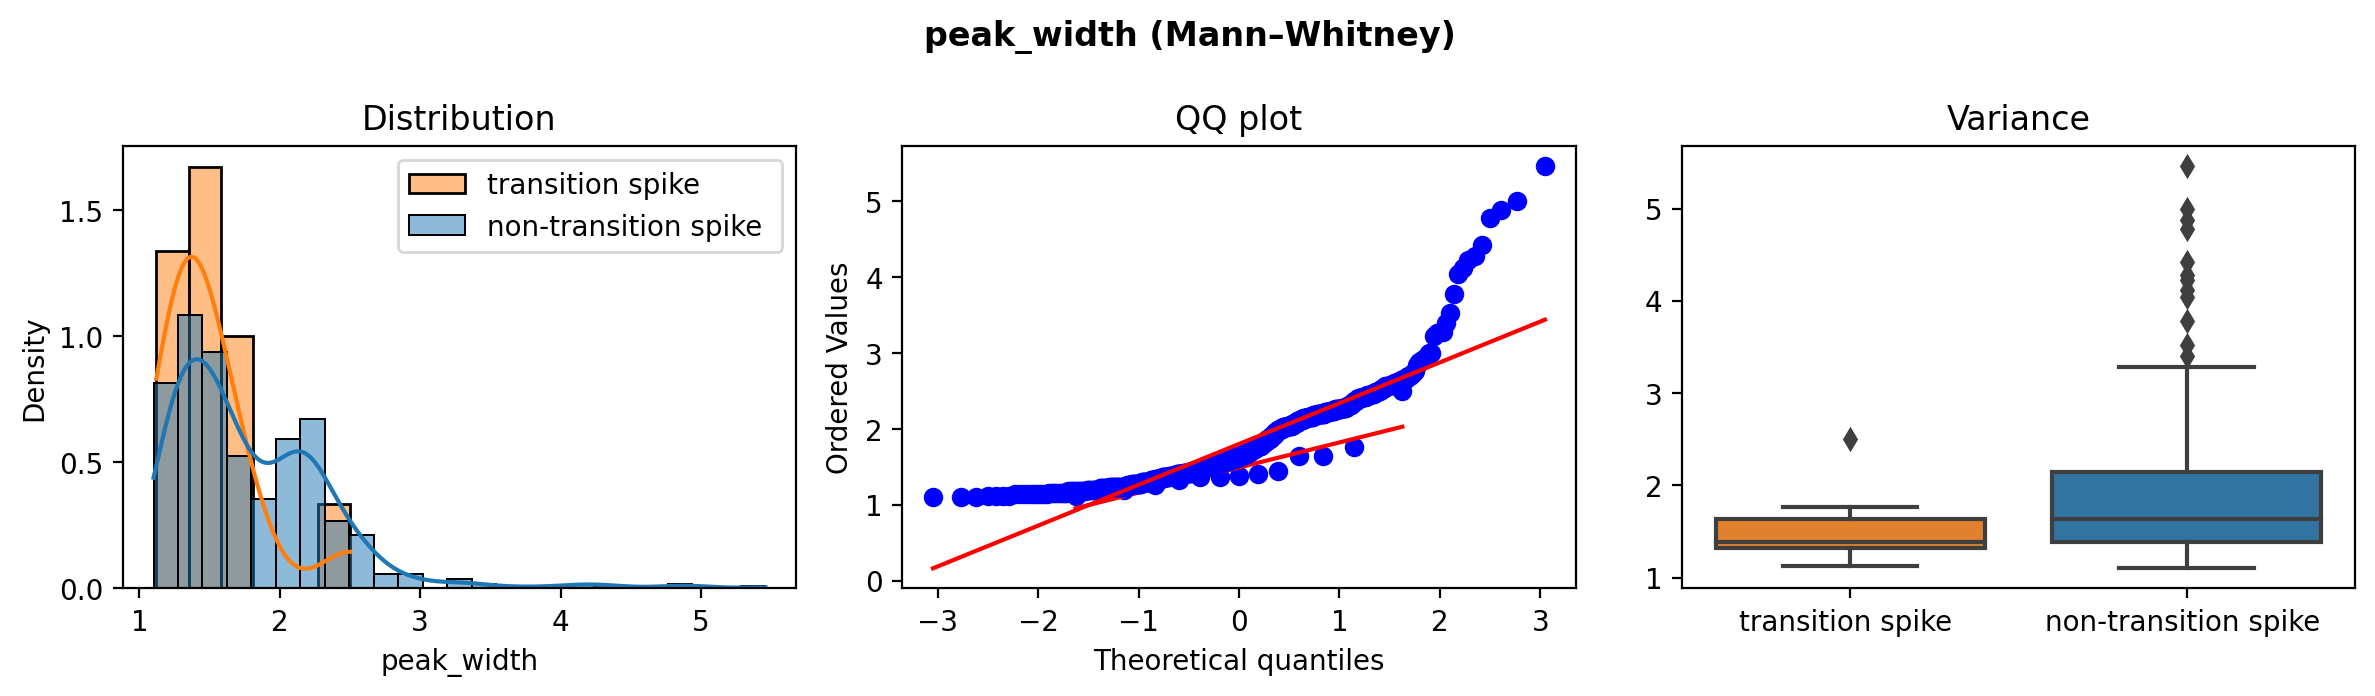

ramp_amp            : t-test        (p=0.1483)


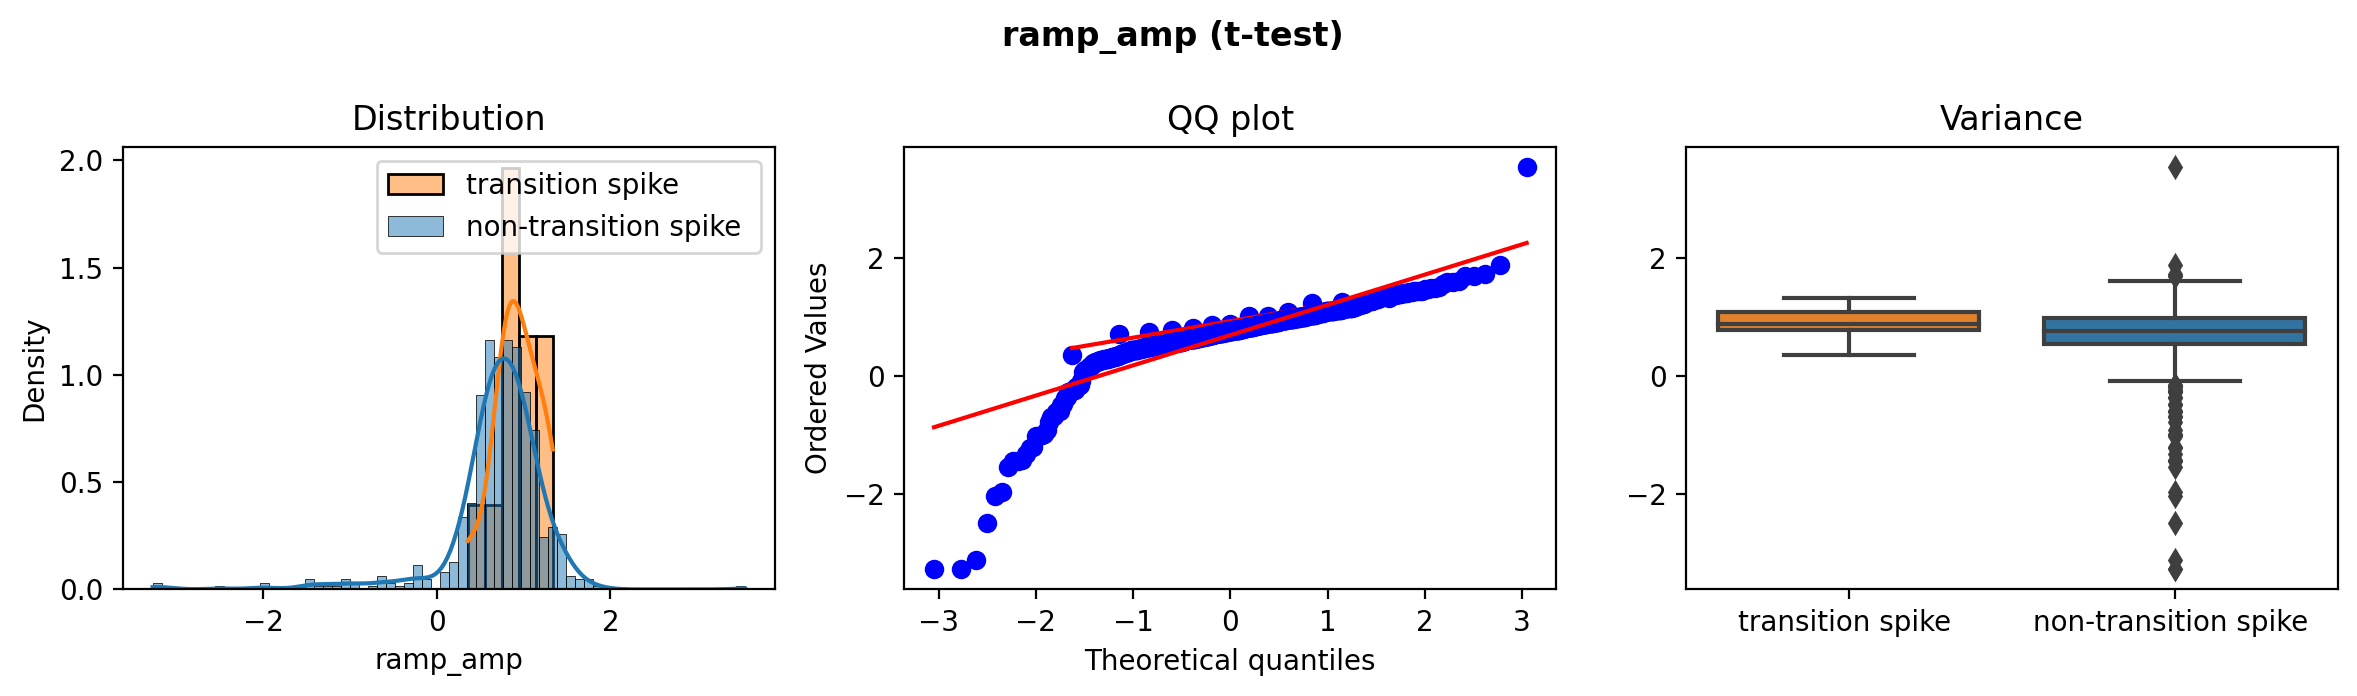

peak_sharpness      : Welch t-test  (p=0.0226)


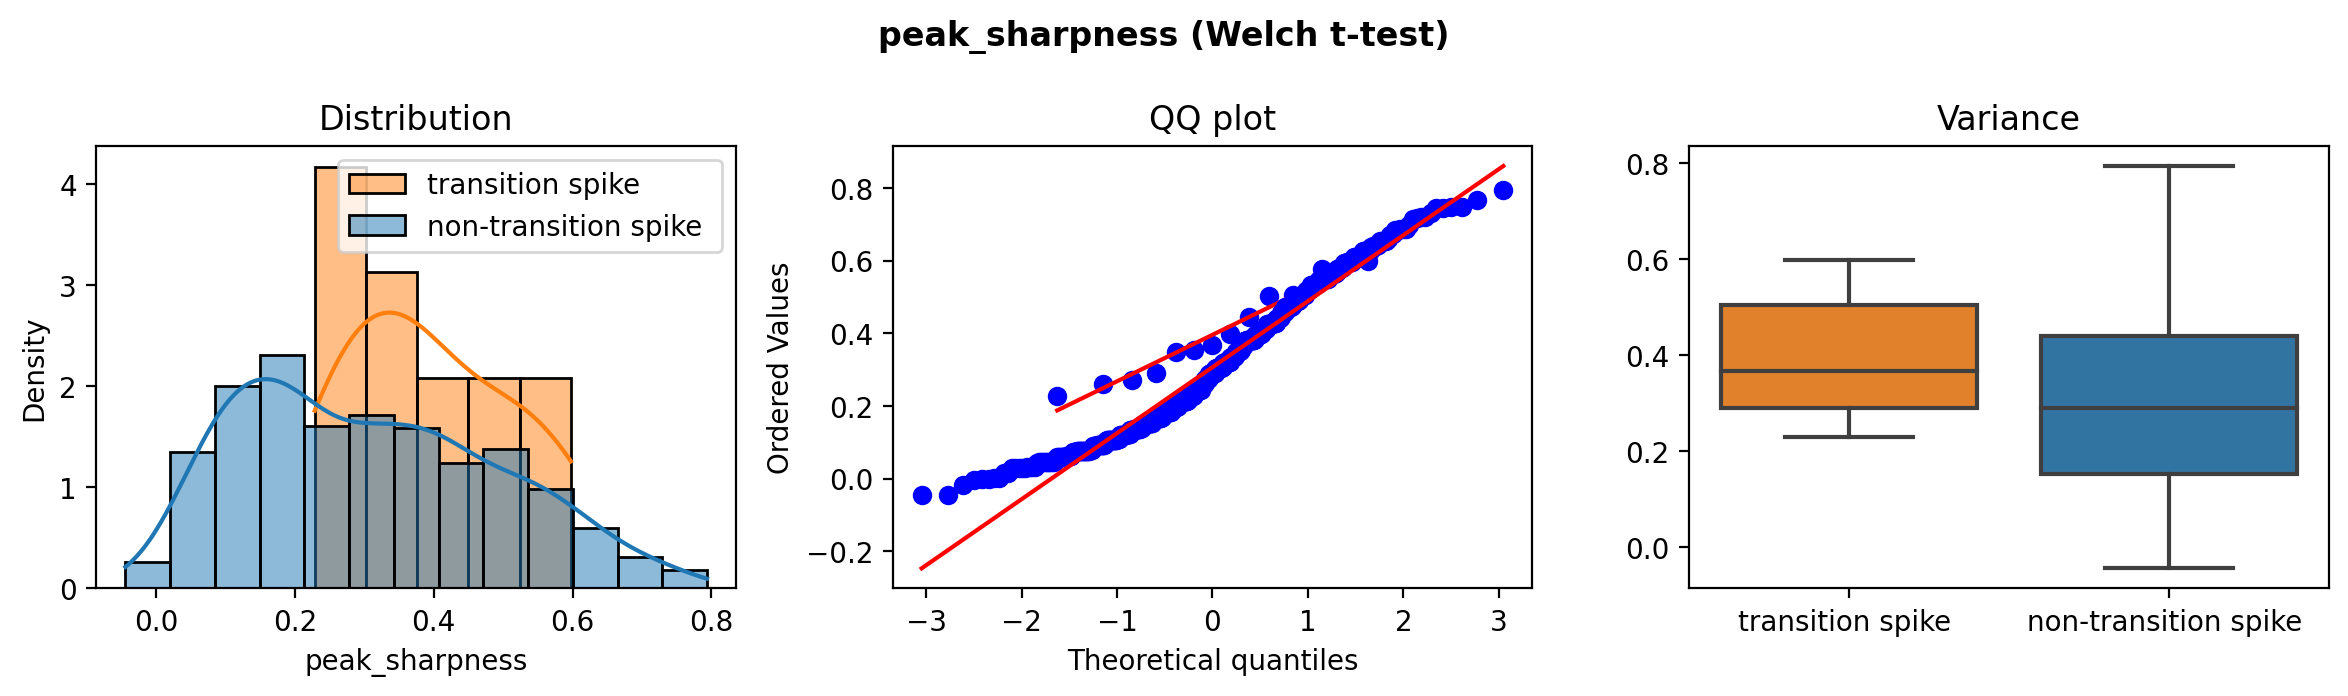

inflection_amp      : t-test        (p=0.1896)


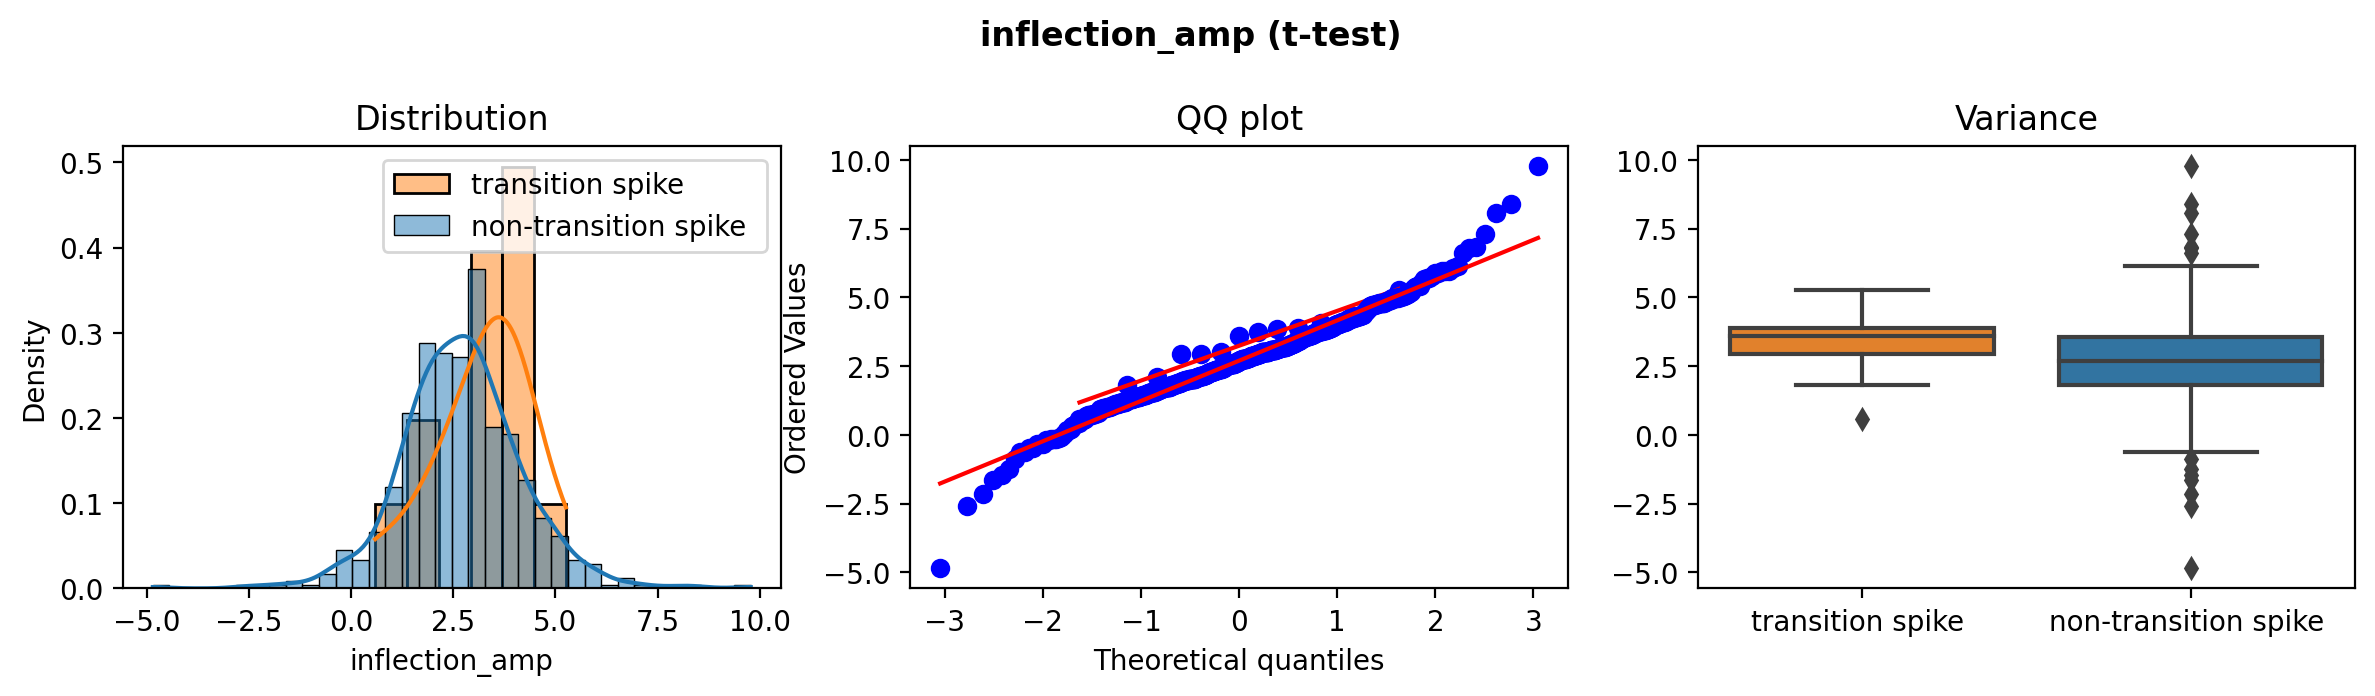

exp_lambda          : Mann–Whitney  (p=0.0417)


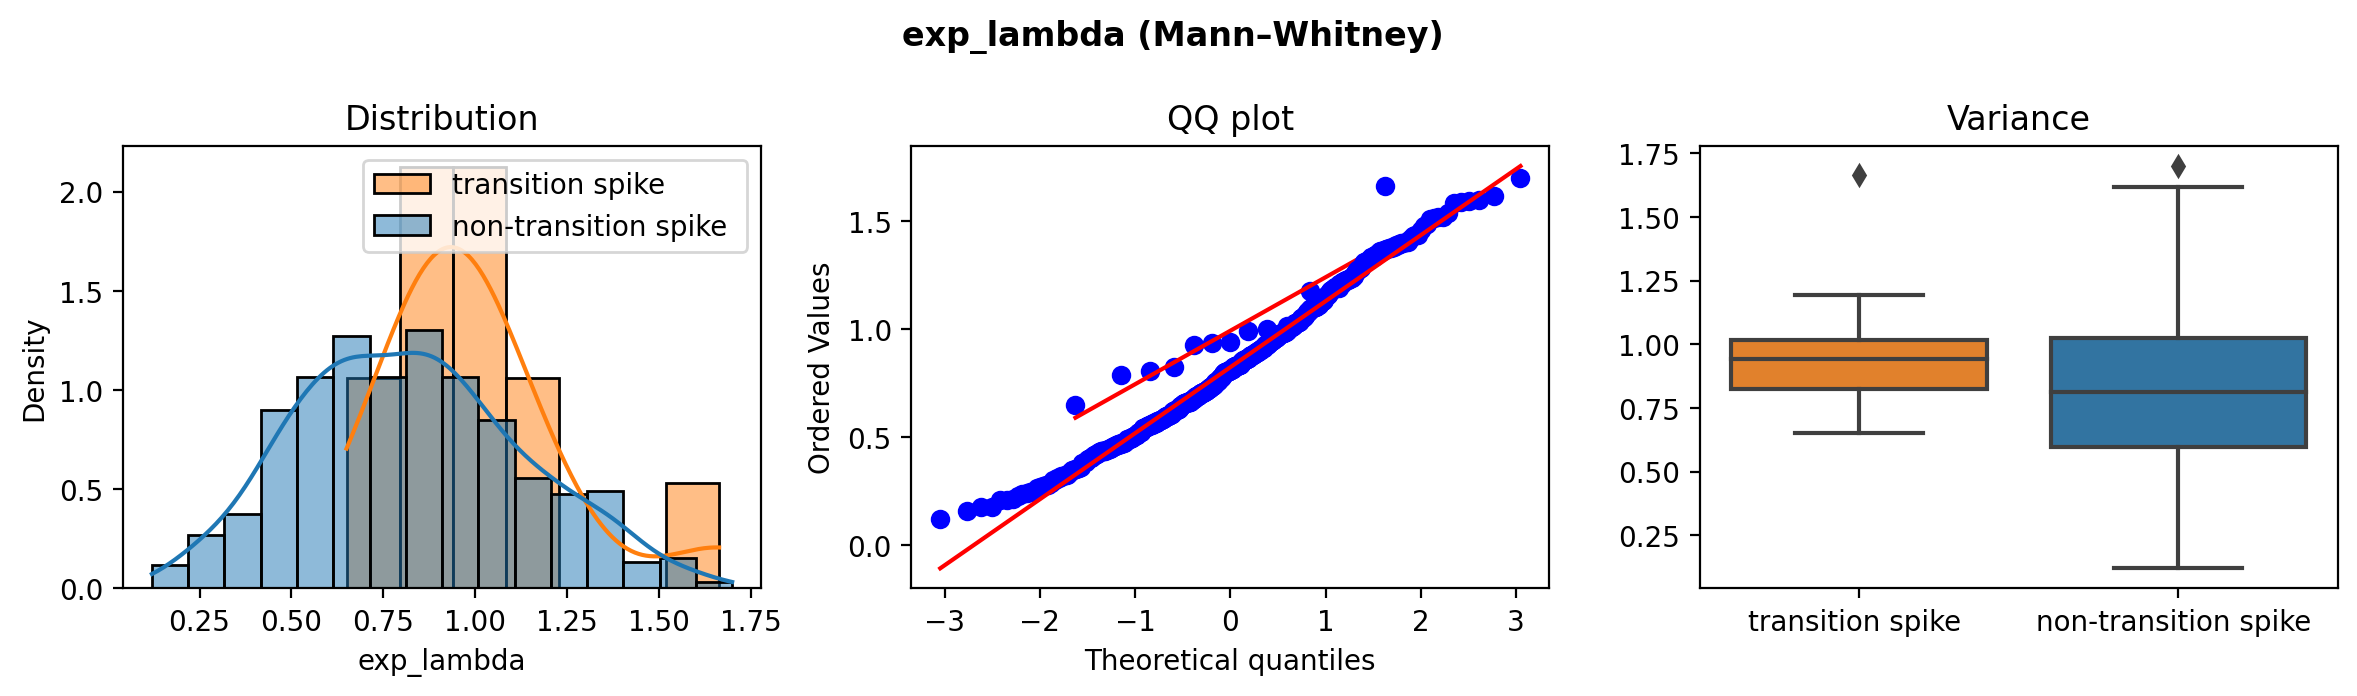

In [22]:



res = compare_feature_groups(
    df_marked,
    features= ["peak_width","ramp_amp","peak_sharpness", "inflection_amp", "exp_lambda"],
    group_col="is_long_to_short_isi_onset",
    groups=(True, False),              
    group_names=("transition spike ","non-transition spike "),  
    show_plots=True
)


### STEP 4: Analyze LFP around transition points

#### Get LFP windows 

Removed 1 transition(s) with next_log_isi > 1.155


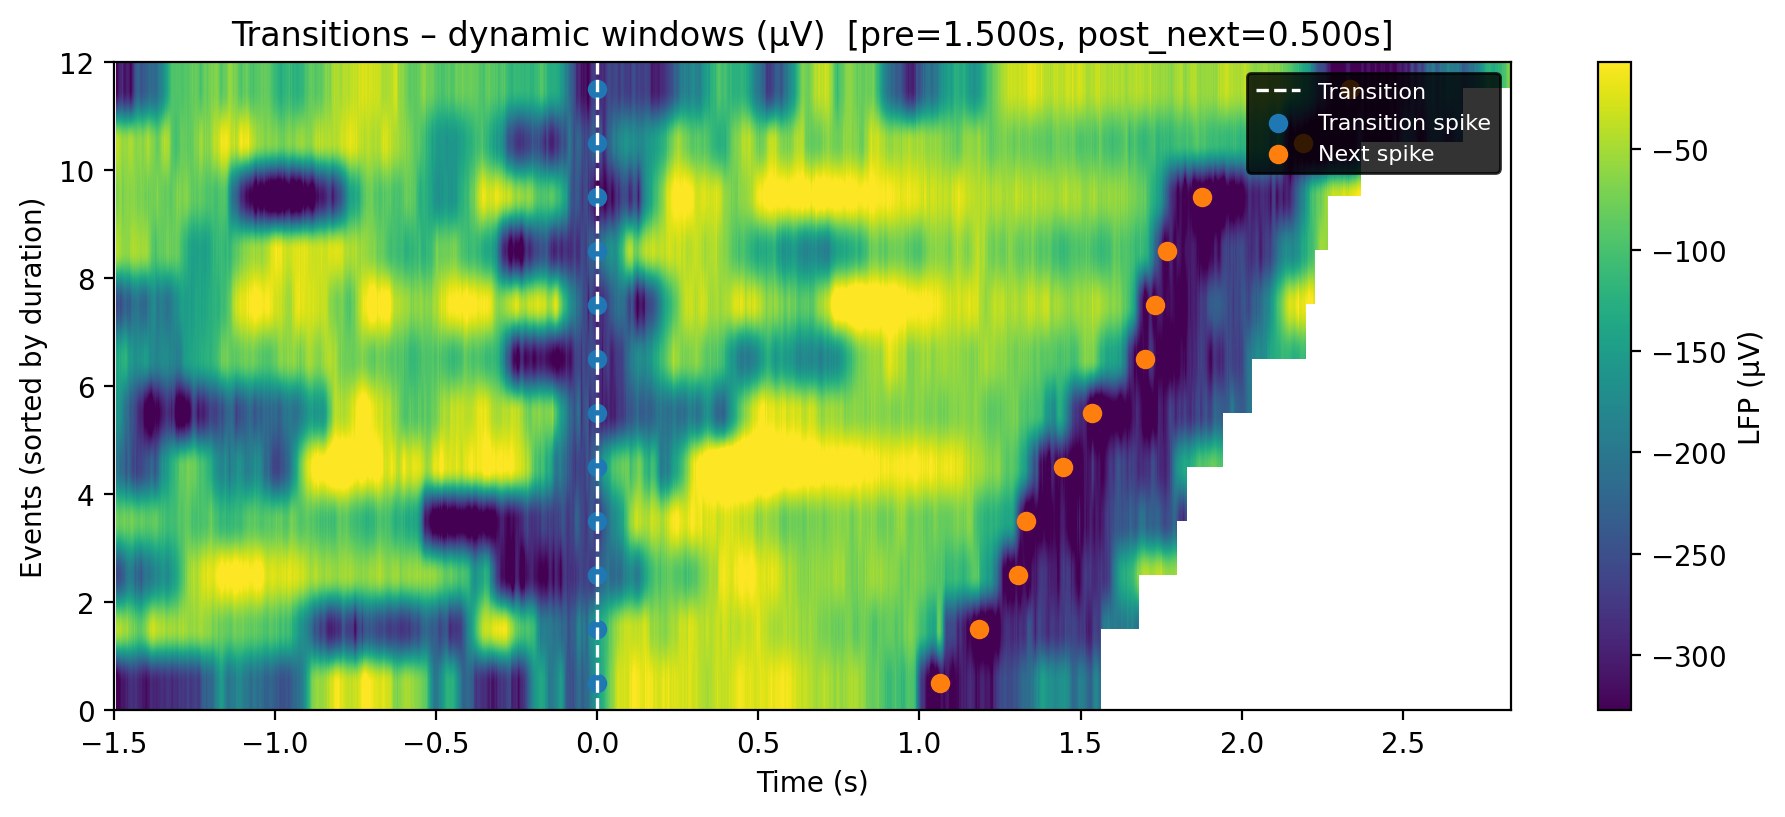

In [23]:

# 1) Compute NEXT-ISI from your spike-time column (in ms → s)
df_marked = df_marked.sort_values("spk_times_ms").reset_index(drop=True)
t_ms = pd.to_numeric(df_marked["spk_times_ms"], errors="coerce")

# time to next spike (ms), last row → NaN
df_marked["next_isi_ms"] = (t_ms.shift(-1) - t_ms).astype(float)
df_marked.loc[df_marked["next_isi_ms"] <= 0, "next_isi_ms"] = np.nan

# seconds and log (natural log to match your existing log_isi scale)
df_marked["next_isi_s"]   = df_marked["next_isi_ms"] / 1000.0
df_marked["next_log_isi"] = np.log(df_marked["next_isi_s"])


# 2) Remove long NEXT-ISI outliers among transitions
mask_trans = df_marked["is_long_to_short_isi_onset"].astype(bool)
isis_next  = df_marked.loc[mask_trans, "next_log_isi"].dropna()

thr = isis_next.mean() + 2 * isis_next.std()
bad = mask_trans & (df_marked["next_log_isi"] > thr)

df_marked.loc[bad, "is_long_to_short_isi_onset"] = False
print(f"Removed {bad.sum()} transition(s) with next_log_isi > {thr:.3f}")

# 3) Rebuild transitions AFTER filtering
transitions = transition_next_isi_windows(
    df_marked, time_col="spk_times_ms", onset_col="is_long_to_short_isi_onset"
)

# 4) Re-extract & plot dynamic windows
pre_s, post_after_next_s = 1.500, 0.500
dyn_df, dyn_wins, dyn_t = extract_transition_windows_dynamic(
    lfp_uv=lfp_filt, fs=lfp_fs,
    transitions_df=transitions,
    pre_s=pre_s, post_after_next_s=post_after_next_s
)

t_next_rel = (dyn_df["next_time_s"] - dyn_df["onset_time_s"]).to_numpy(float)
plot_transition_heatmap(
    windows=dyn_wins, times=dyn_t,
    title=f"Transitions – dynamic windows (µV)  [pre={pre_s:.3f}s, post_next={post_after_next_s:.3f}s]",
    markers={"Transition spike": np.zeros(len(dyn_wins)),
             "Next spike": t_next_rel}
)


#### Control plots - also plot heatmaps for random non transition spikes
We are seeing a drop in LFP voltage before spikes for ALL spikes 

In [24]:
# Match the number of controls to transitions 
n_ctrl = len(dyn_df)  # dyn_df from ransitions pipeline
controls = make_random_control_table(
    df_marked,
    time_col="spk_times_ms",
    onset_col="is_long_to_short_isi_onset",
    n_controls=n_ctrl,
    random_state=42,
)

ctrl_df, ctrl_wins, ctrl_t = extract_transition_windows_dynamic(
    lfp_uv=lfp_filt, fs=lfp_fs,
    transitions_df=controls.rename(columns={"next_spike_time_s":"next_time_s"}),
    pre_s=pre_s, post_after_next_s=post_after_next_s
)


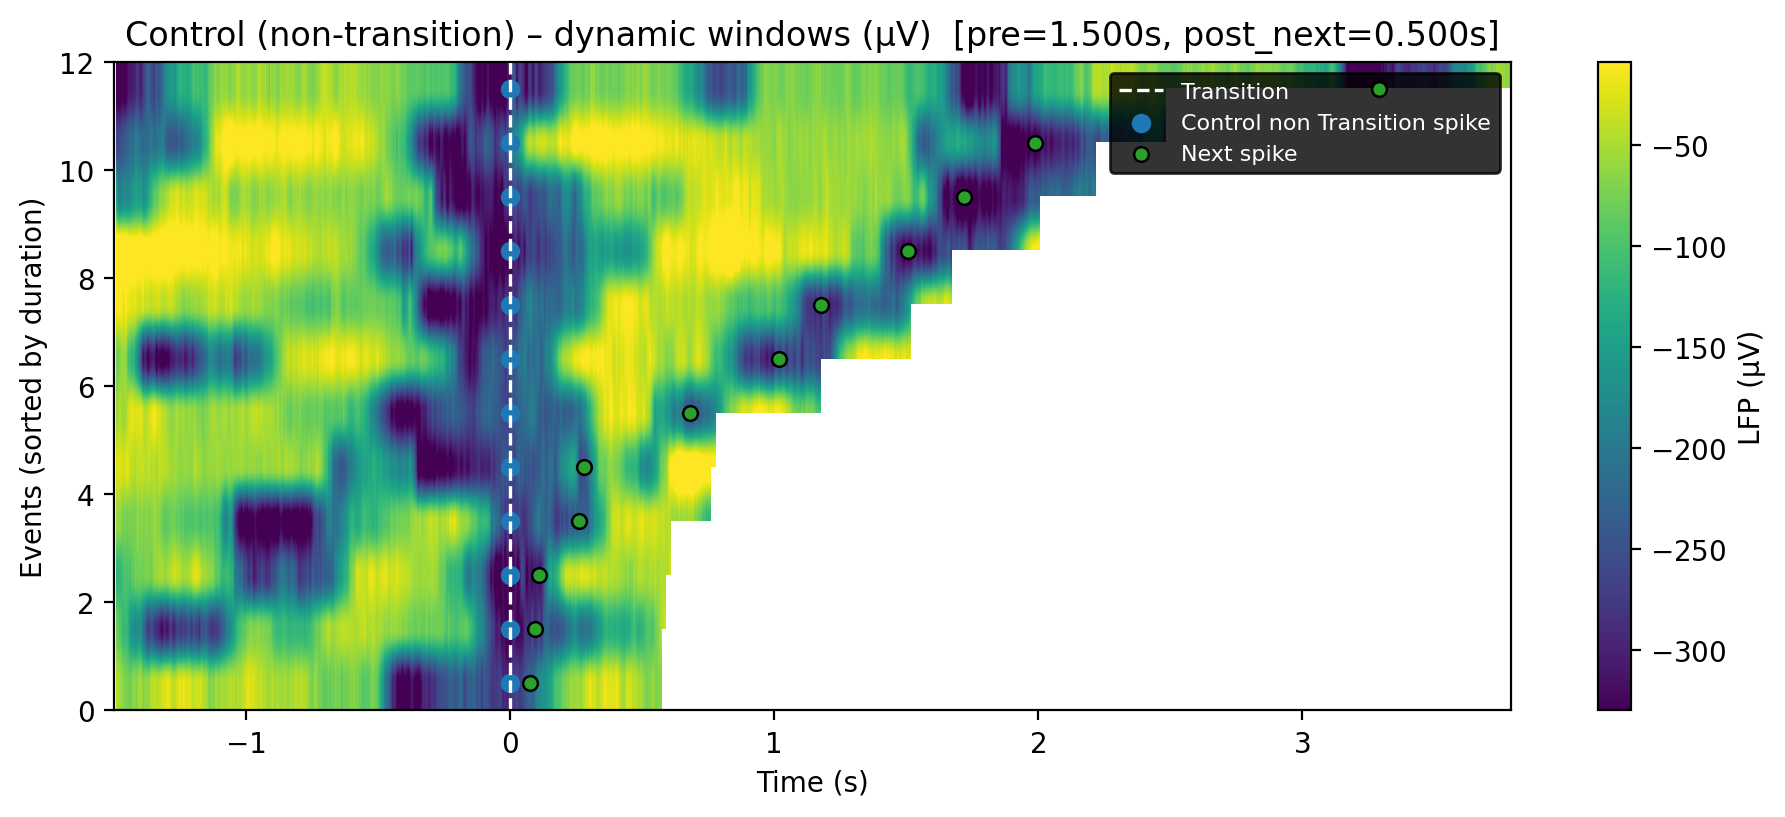

In [25]:
t_next_rel_ctrl = (ctrl_df["next_time_s"] - ctrl_df["onset_time_s"]).to_numpy(float)

plot_transition_heatmap(
    windows=ctrl_wins, times=ctrl_t,
    title=f"Control (non-transition) – dynamic windows (µV)  [pre={pre_s:.3f}s, post_next={post_after_next_s:.3f}s]",
    markers={"Control non Transition spike": np.zeros(len(ctrl_wins)),
             "Next spike": t_next_rel_ctrl},
    marker_style={
        "Anchor": {"s": 28, "facecolors": "white",  "edgecolors": "black", "lw": 0.9, "zorder": 6},
        "Next spike": {"s": 28, "facecolors": "#2ca02c", "edgecolors": "black", "lw": 0.9, "zorder": 6},
    }
)


#### Analyze LFP windows using specparam 

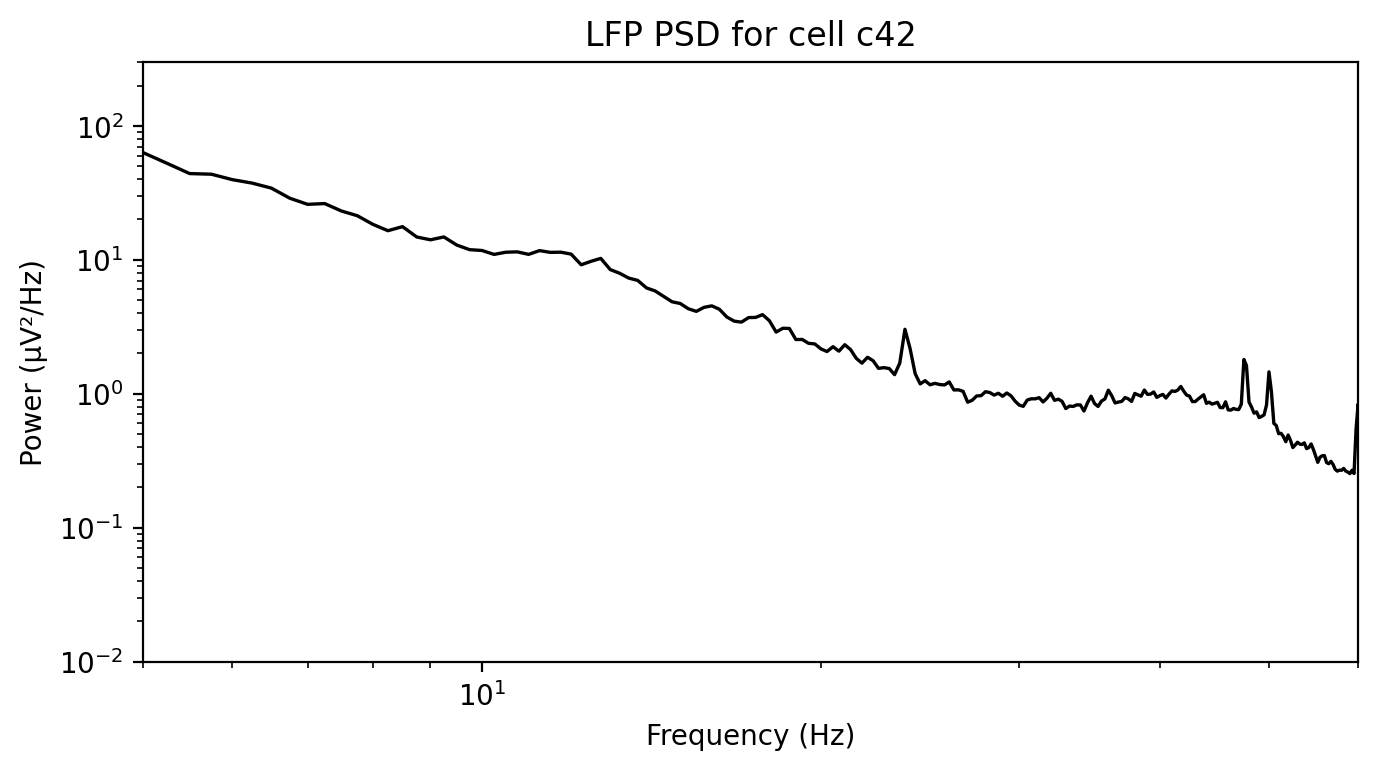

In [26]:
#Show PSD on whole recording before doing timer-resolved approach
# --- Compute PSD ---
fxx, pxx = spectral.compute_spectrum(
    lfp_filt, lfp_fs,
    method='welch',
    window='hann',
    nperseg=int(lfp_fs * 4)
)

# --- Filter for valid range ---
mask = (fxx > 0) & np.isfinite(pxx)
fxx = fxx[mask]
pxx = pxx[mask]

# --- Plot (log–log) ---
plt.figure(figsize=(7, 4))
plt.loglog(fxx, pxx, lw=1.2, color='k')

# Axis limits (normal, predictable)
plt.xlim(5, 60)             # Hz
plt.ylim(10e-3, 300)          
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (µV²/Hz)')
plt.title(f"LFP PSD for cell {cell_num}")



plt.tight_layout()
plt.show()


## Compute power spectra on windows during transition areas using multitaper, and run specparam to extract aperiodic offset, exponent + periodic params (if there) 


####  Fixed - no knee

In [ ]:
# Fixed version (no knee) specparam, per transition window (no internal bars), return spectra
spec_df_fixed, spectra_fixed, spec_fixed_models = run_specparam_on_transition_windows(
    windows=dyn_wins,
    times_rel=dyn_t,
    fs=lfp_fs,
    inner_window_sec=0.500,
    freq_range=(4, 100),
    n_freqs=256,
    time_bandwidth=2.0,
    decim_factor=9,
    progress=True,                   # outer loop only
    n_jobs=1,
    peak_width_limits=(4, 8),
    max_n_peaks=4,
    aperiodic_mode="fixed",
    gamma_band=(30, 60),
    gamma_space="log",
    collect_spectra=True,            # set False if you don't need the matrices
    inner_specparam_progress=False,  # hard-disable internal Specparam tqdm
)


Specparam per epoch:   8%|████████▌                                                                                              | 1/12 [00:10<01:51, 10.15s/it]

In [ ]:
# 1) Per-epoch next-spike time (relative to transition) from your dyn_df
t_next_rel_event = (dyn_df["next_time_s"] - dyn_df["onset_time_s"]).to_numpy(float)

# 2) Map each specparam epoch_id to its event index 
unique_epochs = np.array(sorted(spec_df_fixed["epoch_id"].unique()))


# Build a per-epoch vector of next-spike times aligned to spec_df_knee epoch_ids
if t_next_rel_event.size == unique_epochs.size:
    t_next_rel_epochs = t_next_rel_event.copy()
else:
    # If sizes don't match, create NaNs and fill what we can
    t_next_rel_epochs = np.full(unique_epochs.size, np.nan, float)
 
# 3) Transition is always at 0 per epoch
t0_epochs = np.zeros(unique_epochs.size, dtype=float)




In [ ]:
plot_specparam_transition_heatmap(
    spec_df_fixed,
    param="aperiodic_exponent",  # or "aperiodic_exponent", etc.
    title="Aperiodic exponent around transitions - fixed",
    markers={
        "Transition spike": t0_epochs,
        
        "Next spike": t_next_rel_epochs,
    },
    # optional: tweak marker styles if you want
    marker_style={
        "Transition spike": dict(s=28, facecolors="white", edgecolors="black", lw=0.9, zorder=6),
        "Next spike":       dict(s=28, facecolors="#ff7f0e", edgecolors="black", lw=0.9, zorder=6),
    },
)

In [ ]:
plot_specparam_transition_heatmap(
    spec_df_fixed,
    param="aperiodic_offset",  
    title="Aperiodic offset around transitions - fixed",
    markers={
        "Transition spike": t0_epochs,
        "Next spike": t_next_rel_epochs,
    },

    marker_style={
        "Transition spike": dict(s=28, facecolors="white", edgecolors="black", lw=0.9, zorder=6),
        "Next spike":       dict(s=28, facecolors="#ff7f0e", edgecolors="black", lw=0.9, zorder=6),
    },
)

In [ ]:
plot_specparam_transition_heatmap(
    spec_df_fixed,
    param="gamma_auc",  
    title="Gamma AUC around transitions - fixed",
    markers={
        "Transition spike": t0_epochs,
        "Next spike": t_next_rel_epochs,
    },

    marker_style={
        "Transition spike": dict(s=28, facecolors="white", edgecolors="black", lw=0.9, zorder=6),
        "Next spike":       dict(s=28, facecolors="#ff7f0e", edgecolors="black", lw=0.9, zorder=6),
    },
)

In [ ]:
spec_fixed_models[2].print_results()
spec_fixed_models[2].plot()

#### Knee version

In [ ]:
# Fixed version (no knee) specparam, per transition window (no internal bars), return spectra
spec_df_knee, spectra_knee, spec_knee_models = run_specparam_on_transition_windows(
    windows=dyn_wins,
    times_rel=dyn_t,
    fs=lfp_fs,
    inner_window_sec=1,
    freq_range=(4, 100),
    n_freqs=256,
    time_bandwidth=2.0,
    decim_factor=9,
    progress=True,                   # outer loop only
    n_jobs=1,
    peak_width_limits=(4, 8),
    max_n_peaks=4,
    aperiodic_mode="knee",
    gamma_band=(30, 60),
    gamma_space="log",
    collect_spectra=True,            # set False if you don't need the matrices
    inner_specparam_progress=False,  # hard-disable internal Specparam tqdm
)


In [ ]:
# 1) Per-epoch next-spike time (relative to transition) from your dyn_df
t_next_rel_event = (dyn_df["next_time_s"] - dyn_df["onset_time_s"]).to_numpy(float)

# 2) Map each specparam epoch_id to its event index 
unique_epochs = np.array(sorted(spec_df_knee["epoch_id"].unique()))


# Build a per-epoch vector of next-spike times aligned to spec_df_knee epoch_ids
if t_next_rel_event.size == unique_epochs.size:
    t_next_rel_epochs = t_next_rel_event.copy()
else:
    # If sizes don't match, create NaNs and fill what we can
    t_next_rel_epochs = np.full(unique_epochs.size, np.nan, float)
 
# 3) Transition is always at 0 per epoch
t0_epochs = np.zeros(unique_epochs.size, dtype=float)




In [ ]:
plot_specparam_transition_heatmap(
    spec_df_knee,
    param="aperiodic_exponent",  # or "aperiodic_exponent", etc.
    title="Aperiodic exponent around transitions - knee",
    markers={
        "Transition spike": t0_epochs,
        
        "Next spike": t_next_rel_epochs,
    },
   
    marker_style={
        "Transition spike": dict(s=28, facecolors="white", edgecolors="black", lw=0.9, zorder=6),
        "Next spike":       dict(s=28, facecolors="#ff7f0e", edgecolors="black", lw=0.9, zorder=6),
    },
)

In [ ]:
plot_specparam_transition_heatmap(
    spec_df_knee,
    param="aperiodic_offset",  
    title="Aperiodic offset around transitions - knee",
    markers={
        "Transition spike": t0_epochs,
        "Next spike": t_next_rel_epochs,
    },

    marker_style={
        "Transition spike": dict(s=28, facecolors="white", edgecolors="black", lw=0.9, zorder=6),
        "Next spike":       dict(s=28, facecolors="#ff7f0e", edgecolors="black", lw=0.9, zorder=6),
    },
)

In [ ]:
plot_specparam_transition_heatmap(
    spec_df_knee,
    param="aperiodic_knee",  
    title="Aperiodic knee around transitions - knee",
    markers={
        "Transition spike": t0_epochs,
        "Next spike": t_next_rel_epochs,
    },

    marker_style={
        "Transition spike": dict(s=28, facecolors="white", edgecolors="black", lw=0.9, zorder=6),
        "Next spike":       dict(s=28, facecolors="#ff7f0e", edgecolors="black", lw=0.9, zorder=6),
    },
)

In [ ]:
plot_specparam_transition_heatmap(
    spec_df_knee,
    param="gamma_auc",  
    title="Gamma AUC around transitions - knee",
    markers={
        "Transition spike": t0_epochs,
        "Next spike": t_next_rel_epochs,
    },

    marker_style={
        "Transition spike": dict(s=28, facecolors="white", edgecolors="black", lw=0.9, zorder=6),
        "Next spike":       dict(s=28, facecolors="#ff7f0e", edgecolors="black", lw=0.9, zorder=6),
    },
)

In [ ]:
spec_knee_models[2].print_results()
spec_knee_models[2].plot()

Knee and fixed results are identical, moving on only with the fixed version 

#### Spectrum visualization

In [ ]:
epoch_idx = 3  # pick any transition window
spec = spectra_fixed[epoch_idx]  # (n_bins, n_freqs)
freqs = np.linspace(1, 60, spec.shape[1])

plt.figure(figsize=(6,4))
plt.plot(freqs, spec.mean(axis=0))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (µV²/Hz)")
plt.title(f"Mean spectrum (epoch {epoch_idx})")
plt.yscale("log")
plt.xscale("log")
plt.show()

#### Normalized time resolved plots

In [ ]:
# 1) Make the mean spectrogram
Tgrid, F, mean_spec = mean_spectrogram_across_epochs(
    spectra_fixed, spec_df_fixed,
    freq_range=(1, 60),
    n_freqs=spectra_fixed[0].shape[1],
    n_time=220,
    use_log=True
)

# 2) Compute the mean next-ISI (seconds) from your transition dataframe
# If you already have t_next_rel = next_time_s - onset_time_s:
mean_next = float(np.nanmean(t_next_rel))  # vertical dashed line location
# (If you don't have t_next_rel yet, compute it from your transitions DF.)

# 3) Plot
plot_mean_spectrogram(Tgrid, F, mean_spec, mean_next_isi=mean_next)


In [ ]:
mean_next = float(np.nanmean(t_next_rel))
plot_exponent_and_gamma(spec_df_fixed, mean_next_isi=mean_next)


### Compare with controls (non transitions)

In [ ]:
spec_df_ctrl, spectra_ctrl, models_ctrl = run_specparam_on_transition_windows(
    windows=ctrl_wins,
    times_rel=ctrl_t,
    fs=lfp_fs,
    inner_window_sec=0.500,      # your bin size
    freq_range=(4, 100),
    n_freqs=256,
    time_bandwidth=2.0,
    decim_factor=9,
    progress=True,               # outer loop bar only
    n_jobs=1,

    peak_width_limits=(4, 8),
    max_n_peaks=2,
    aperiodic_mode="fixed",      # or "knee"
    periodic_mode="gaussian",
    verbose=False,

    gamma_band=(30, 55),
    gamma_space="log",
    compute_gamma_auc=True,

    collect_spectra=True,        # keep raw (n_bins, n_freqs) per epoch
    inner_specparam_progress=False
)


In [ ]:
plot_specparam_transition_heatmap(
    spec_df_ctrl,
    param="aperiodic_exponent",  # or "aperiodic_exponent", etc.
    title="Aperiodic exponent around transitions - fixed - CONTROL ",
    markers={
        "Transition spike": t0_epochs,
        
        "Next spike": t_next_rel_ctrl,
    },
   
    marker_style={
        "Transition spike": dict(s=28, facecolors="white", edgecolors="black", lw=0.9, zorder=6),
        "Next spike":       dict(s=28, facecolors="#ff7f0e", edgecolors="black", lw=0.9, zorder=6),
    },
)

In [ ]:
plot_specparam_transition_heatmap(
    spec_df_ctrl,
    param="gamma_auc",  # or "aperiodic_exponent", etc.
    title="Gamma AUC around transitions - fixed - CONTROL ",
    markers={
        "Transition spike": t0_epochs,
        
        "Next spike": t_next_rel_ctrl,
    },
   
    marker_style={
        "Transition spike": dict(s=28, facecolors="white", edgecolors="black", lw=0.9, zorder=6),
        "Next spike":       dict(s=28, facecolors="#ff7f0e", edgecolors="black", lw=0.9, zorder=6),
    },
)

In [ ]:
models_ctrl[2].print_results()
models_ctrl[2].plot(bands=bands)

In [ ]:
##### Mea spectogram and time course params
# Average next-ISI for vertical reference line
mean_next_isi_ctrl = float(np.nanmean(t_next_rel_ctrl)) if len(t_next_rel_ctrl) else None

Tgrid, F, mean_spec = mean_spectrogram_across_epochs(
    spectra_ctrl, spec_df_ctrl,
    freq_range=(1, 60),
    n_freqs=spectra_fixed[0].shape[1],
    n_time=220,
    use_log=True
)

plot_mean_spectrogram(Tgrid, F, mean_spec, mean_next_isi=mean_next_isi_ctrl)

plot_exponent_and_gamma(spec_df_ctrl, n_time=220, mean_next_isi=mean_next_isi_ctrl)
